***The following notebook identifies which subhalos are associated with the LMC and compares their normalized SHMF with the SymphonyLMC suite***

In [27]:
# Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import symlib

In [28]:
# Replace with your directories
base_dir = "/data/darkmatter/programs/symlib/standard/"
suite_name = "MWest"

base_dir_SymphonyLMC = "/data/darkmatter/programs/symlib/standard/SMW_LMC/"
suite_name_SymphonyLMC = "SymphonyLMC"

base_dir_symphony = "/data/darkmatter/programs/symlib/standard/SMW/"

#Which redshifts do you want the subhalos associated with the LMC to count at
target_redshifts = [3, 2, 1, 0.5, 0]

***The lmc indices were found from the LMC_idx_indentifier_mwest notebook***

In [29]:
lmc_index_by_host = {
    0: 1,   # Halo004
    1: 5,   # Halo113
    2: 1,   # Halo169
    3: 1,   # Halo170
    4: 1,   # Halo222
    5: 7,   # Halo229
    6: 4,   # Halo282
    7: 2,   # Halo327
    8: 1,   # Halo349
    9: 2,   # Halo407
    10: 1,  # Halo453
    11: 1,  # Halo476
    12: 2,  # Halo659
    13: 1,  # Halo666
    14: 1,  # Halo719
    15: 6,  # Halo747
    16: 3,  # Halo756
    17: 3,  # Halo788
    18: 1,  # Halo975
    19: 1,  # Halo983
}

***Helper functions***

In [30]:
def get_host_name_from_index(base_dir, suite_name, i_host):
    sim_dir = symlib.get_host_directory(base_dir, suite_name, i_host)
    return os.path.basename(sim_dir.rstrip("/"))

def find_pre_infall_snapshot(host_track, lmc_track, mode="crossing"):
    """
    Return snapshot index just before LMC infall.

    mode="crossing":
        first snapshot where d < Rvir_host, then return one before that

    mode="outside_both":
        working backward from late times, first snapshot where
        d > Rvir_host + Rvir_lmc
    """
    host_x = host_track["x"]
    lmc_x  = lmc_track["x"]

    d = np.sqrt(np.sum((lmc_x - host_x)**2, axis=1))
    rvir_host = host_track["rvir"]
    rvir_lmc  = lmc_track["rvir"]

    ok = host_track["ok"] & lmc_track["ok"]

    if mode == "crossing":
        inside = ok & (d < rvir_host)
        idx = np.where(inside)[0]
        if len(idx) == 0:
            return None
        i_cross = idx[0]
        return i_cross - 1 if i_cross > 0 else None

    elif mode == "outside_both":
        for i in range(len(d) - 1, -1, -1):
            if not ok[i]:
                continue
            if d[i] > (rvir_host[i] + rvir_lmc[i]):
                return i
        return None

    else:
        raise ValueError("mode must be 'crossing' or 'outside_both'")


def analyze_symfind_lmc_shmf(
    base_dir,
    suite_name,
    lmc_index_by_host,
    log_m_min=8,
    log_m_max=12,
    n_bin=200,
    analysis_snap=-1,
    pre_infall_mode="outside_both",
    mass_def="mpeak",
    association_mode="ever_inside_lmc",
    make_plot=True,
    verbose=True,
):
    """
    Build average cumulative SHMFs for:
      - all surviving MW subhalos inside host Rvir at analysis snapshot
      - surviving LMC-associated subhalos
      - surviving non-LMC-associated subhalos
    """
    bins = np.logspace(log_m_min, log_m_max, n_bin + 1)

    # accumulate raw cumulative counts, then normalize by used hosts
    N_total = np.zeros(n_bin)
    N_lmc   = np.zeros(n_bin)
    N_non   = np.zeros(n_bin)

    per_host_rows = []
    n_used_hosts = 0
    n_hosts = symlib.n_hosts(suite_name)

    for i_host in range(n_hosts):
        if i_host not in lmc_index_by_host:
            if verbose:
                print(f"Skipping host {i_host}: no LMC analog supplied")
            continue

        sim_dir = symlib.get_host_directory(base_dir, suite_name, i_host)
        host_name = os.path.basename(sim_dir.rstrip("/"))

        h, hist = symlib.read_subhalos(sim_dir)
        lmc_idx = lmc_index_by_host[i_host]

        if lmc_idx <= 0 or lmc_idx >= len(h):
            if verbose:
                print(f"Skipping {host_name}: invalid lmc_idx={lmc_idx}")
            continue

        host_track = h[0]
        lmc_track  = h[lmc_idx]

        n_snap = h.shape[1]
        i_final = analysis_snap if analysis_snap >= 0 else n_snap + analysis_snap
        if i_final < 0 or i_final >= n_snap:
            raise ValueError("analysis_snap out of range")

        i_pre = find_pre_infall_snapshot(host_track, lmc_track, mode=pre_infall_mode)
        if i_pre is None:
            if verbose:
                print(f"Skipping {host_name}: could not find pre-infall snapshot")
            continue

        #suviving subhalos at analysis snapshot
        host_rvir_now = h[0, i_final]["rvir"]
        sub_x_now = h[:, i_final]["x"]
        r_host_now = np.sqrt(np.sum(sub_x_now**2, axis=1))

        ok_now = h["ok"][:, i_final]
        inside_host_now = ok_now & (r_host_now < host_rvir_now)
        inside_host_now[0] = False  # exclude main host

        #lmc association
        if association_mode == "pre_infall":
            sub_x_pre = h[:, i_pre]["x"]
            lmc_x_pre = h[lmc_idx, i_pre]["x"]
            r_sub_lmc_pre = np.sqrt(np.sum((sub_x_pre - lmc_x_pre)**2, axis=1))

            ok_pre = h["ok"][:, i_pre]
            rvir_lmc_pre = h[lmc_idx, i_pre]["rvir"]

            lmc_assoc = ok_pre & (r_sub_lmc_pre < rvir_lmc_pre)

        elif association_mode == "ever_inside_lmc":
            lmc_assoc = np.zeros(len(h), dtype=bool)
            for s in range(i_pre + 1):
                ok_s = h["ok"][:, s] & h[lmc_idx, s]["ok"]
                sub_x_s = h[:, s]["x"]
                lmc_x_s = h[lmc_idx, s]["x"]
                r_sub_lmc_s = np.sqrt(np.sum((sub_x_s - lmc_x_s)**2, axis=1))
                rvir_lmc_s = h[lmc_idx, s]["rvir"]
                lmc_assoc |= ok_s & (r_sub_lmc_s < rvir_lmc_s)

        else:
            raise ValueError("association_mode must be 'pre_infall' or 'ever_inside_lmc'")

        # exclude host and LMC analog itself
        lmc_assoc[0] = False
        lmc_assoc[lmc_idx] = inside_host_now[lmc_idx]

        lmc_assoc_survive_now = lmc_assoc & inside_host_now
        non_lmc_survive_now   = inside_host_now & (~lmc_assoc_survive_now)

        # masses for SHMF
        if mass_def == "mpeak":
            masses = hist["mpeak"]
            xlab = r"$M_{\rm sub,peak}\,[M_\odot]$"
        elif mass_def == "mvir_now":
            masses = h[:, i_final]["mvir"]
            xlab = r"$M_{\rm sub}(z=0)\,[M_\odot]$"
        else:
            raise ValueError("mass_def must be 'mpeak' or 'mvir_now'")

        masses_total = masses[inside_host_now]
        masses_lmc   = masses[lmc_assoc_survive_now]
        masses_non   = masses[non_lmc_survive_now]

        n_total, _ = np.histogram(masses_total, bins=bins)
        n_lmc, _   = np.histogram(masses_lmc, bins=bins)
        n_non, _   = np.histogram(masses_non, bins=bins)

        N_total += np.cumsum(n_total[::-1])[::-1]
        N_lmc   += np.cumsum(n_lmc[::-1])[::-1]
        N_non   += np.cumsum(n_non[::-1])[::-1]

        # per host summary numbers
        lmc_fraction = (
            np.sum(lmc_assoc_survive_now) / np.sum(inside_host_now)
            if np.sum(inside_host_now) > 0 else np.nan
        )

        per_host_rows.append({
            "host_index": i_host,
            "host_name": host_name,
            "lmc_idx": int(lmc_idx),
            "i_pre": int(i_pre),
            "N_total_now": int(np.sum(inside_host_now)),
            "N_lmc_now": int(np.sum(lmc_assoc_survive_now)),
            "N_non_now": int(np.sum(non_lmc_survive_now)),
            "N_lmc_candidates_prehistory": int(np.sum(lmc_assoc)),
            "frac_lmc_now": float(lmc_fraction),
            "host_rvir_now": float(host_rvir_now),
        })

        n_used_hosts += 1

        if verbose:
            print(
                f"{host_name}: "
                f"lmc_idx={lmc_idx}, i_pre={i_pre}, "
                f"N_total_now={np.sum(inside_host_now)}, "
                f"N_lmc_now={np.sum(lmc_assoc_survive_now)}, "
                f"N_non_now={np.sum(non_lmc_survive_now)}, "
                f"frac_lmc_now={lmc_fraction:.3f}"
            )

    if n_used_hosts == 0:
        raise RuntimeError("No hosts were successfully analyzed.")

    N_total /= n_used_hosts
    N_lmc   /= n_used_hosts
    N_non   /= n_used_hosts

    per_host_df = pd.DataFrame(per_host_rows)

    if make_plot:
        plt.figure(figsize=(7.5, 5.5))
        plt.plot(bins[:-1], N_total, label="MW total")
        plt.plot(bins[:-1], N_lmc, "--", label="LMC-associated")
        plt.plot(bins[:-1], N_non, "-.", label="Non-LMC-associated")
        plt.xscale("log")
        plt.yscale("log")
        plt.xlabel(xlab)
        plt.ylabel(r"$\langle N(>M)\rangle$")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return per_host_df, bins[:-1], N_total, N_lmc, N_non


def summarize_shmf_results(per_host_df, mass_bins, N_total, N_lmc, N_non, label="run"):
    """
    Build reportable summary statistics.
    """
    stats = {}

    stats["n_hosts_used"] = int(len(per_host_df))
    stats["mean_N_total_now"] = float(per_host_df["N_total_now"].mean())
    stats["std_N_total_now"] = float(per_host_df["N_total_now"].std(ddof=1))
    stats["mean_N_lmc_now"] = float(per_host_df["N_lmc_now"].mean())
    stats["std_N_lmc_now"] = float(per_host_df["N_lmc_now"].std(ddof=1))
    stats["mean_N_non_now"] = float(per_host_df["N_non_now"].mean())
    stats["std_N_non_now"] = float(per_host_df["N_non_now"].std(ddof=1))
    stats["mean_frac_lmc_now"] = float(per_host_df["frac_lmc_now"].mean())
    stats["std_frac_lmc_now"] = float(per_host_df["frac_lmc_now"].std(ddof=1))
    stats["median_frac_lmc_now"] = float(per_host_df["frac_lmc_now"].median())

    # useful SHMF thresholds
    thresholds = [1e8, 3e8, 1e9, 3e9, 1e10]

    def interp_cumulative(x, y, x0):
        # x increasing, y cumulative decreasing
        # interpolate in log-x
        lx = np.log10(x)
        lx0 = np.log10(x0)
        return float(np.interp(lx0, lx, y))

    for thr in thresholds:
        tag = f"{thr:.0e}".replace("+0", "").replace("+", "")
        stats[f"N_total_gt_{tag}"] = interp_cumulative(mass_bins, N_total, thr)
        stats[f"N_lmc_gt_{tag}"]   = interp_cumulative(mass_bins, N_lmc, thr)
        stats[f"N_non_gt_{tag}"]   = interp_cumulative(mass_bins, N_non, thr)

    stats_df = pd.DataFrame([stats])
    stats_df.insert(0, "label", label)
    return stats_df

def get_particle_mass_safe(sim_dir, scale):
    param = symlib.simulation_parameters(sim_dir)

    if isinstance(param, dict):
        for key in ["mp", "m_p", "particle_mass"]:
            if key in param:
                return float(param[key])

    out = symlib.set_units_parameters(scale, param)

    if isinstance(out, dict):
        for key in ["mp", "m_p", "particle_mass"]:
            if key in out:
                return float(out[key])

    if isinstance(out, tuple):
        for item in out:
            if isinstance(item, dict):
                for key in ["mp", "m_p", "particle_mass"]:
                    if key in item:
                        return float(item[key])
            if isinstance(item, (int, float, np.floating)):
                return float(item)

    raise RuntimeError("Could not determine particle mass.")


def build_lmc_membership_by_snapshot(
    h,
    lmc_idx,
    i_pre,
    include_lmc_itself=True,
):
    """
    Correct snapshot-dependent LMC association.

    For snap <= i_pre:
        associated = ever inside Rvir,LMC up to that snapshot.

    For snap > i_pre:
        associated = frozen list from i_pre.
    """

    n_sub = len(h)
    n_snap = h.shape[1]

    membership_by_snap = {}
    ever_inside_running = np.zeros(n_sub, dtype=bool)
    frozen_preinfall_lmc_assoc = None

    for snap in range(n_snap):

        if snap <= i_pre:

            if h[lmc_idx, snap]["ok"]:

                ok_s = h["ok"][:, snap]

                sub_x = h[:, snap]["x"]
                lmc_x = h[lmc_idx, snap]["x"]

                r_sub_lmc = np.sqrt(np.sum((sub_x - lmc_x) ** 2, axis=1))
                rvir_lmc = h[lmc_idx, snap]["rvir"]

                inside_lmc_now = ok_s & (r_sub_lmc < rvir_lmc)

                ever_inside_running |= inside_lmc_now

            current_lmc_assoc = ever_inside_running.copy()

            if snap == i_pre:
                frozen_preinfall_lmc_assoc = current_lmc_assoc.copy()

        else:
            current_lmc_assoc = frozen_preinfall_lmc_assoc.copy()

        current_lmc_assoc[0] = False

        if include_lmc_itself:
            current_lmc_assoc[lmc_idx] = True
        else:
            current_lmc_assoc[lmc_idx] = False

        membership_by_snap[snap] = current_lmc_assoc.copy()

    return membership_by_snap

***LMC associated subhalos for MWest***

In [31]:
def analyze_lmc_assoc_shmf_snapshot_dependent(
    base_dir,
    suite_name,
    lmc_index_by_host,
    target_redshifts,
    log_m_min=8,
    log_m_max=12,
    n_bin=80,
    pre_infall_mode="crossing",
    mass_def="mpeak",
    min_particles=300,
    require_survive_z0=True,
    require_within_lmc_rvir=True,
    include_lmc_itself=True,
    make_plot=True,
    verbose=True,
):
    """
    Redshift evolution of LMC-associated SHMF.

    Correct association rule:
    - Before LMC infall:
        associated if ever inside Rvir,LMC up to that snapshot.
    - After LMC infall:
        associated if ever inside Rvir,LMC before LMC infall.

    Then cuts:
    - survives to z=0, optional (Dr. Nadler has this set to False)
    - resolved: mass >= min_particles * mp
    - exists at target snapshot
    - within Rvir,LMC at target snapshot, optional (Dr. Nadler has this set to True)
    """

    bins = np.logspace(log_m_min, log_m_max, n_bin + 1)
    mass_bins = bins[:-1]

    curves_by_z = {z: np.zeros(n_bin) for z in target_redshifts}

    selected_rows = []
    per_host_rows = []
    curve_rows = []

    n_used_hosts = 0
    n_hosts = symlib.n_hosts(suite_name)

    for i_host in range(n_hosts):

        if i_host not in lmc_index_by_host:
            continue

        sim_dir = symlib.get_host_directory(base_dir, suite_name, i_host)
        host_name = os.path.basename(sim_dir.rstrip("/"))

        h, hist = symlib.read_subhalos(sim_dir)
        scale = symlib.scale_factors(sim_dir)
        redshifts = 1.0 / scale - 1.0

        lmc_idx = lmc_index_by_host[i_host]

        if lmc_idx <= 0 or lmc_idx >= len(h):
            if verbose:
                print(f"Skipping {host_name}: bad lmc_idx={lmc_idx}")
            continue

        i_pre = find_pre_infall_snapshot(
            h[0],
            h[lmc_idx],
            mode=pre_infall_mode,
        )

        if i_pre is None:
            if verbose:
                print(f"Skipping {host_name}: no pre-infall snapshot")
            continue

        mp = get_particle_mass_safe(sim_dir, scale)
        m_res = min_particles * mp

        if mass_def == "mpeak":
            masses = hist["mpeak"]
            xlab = r"$M_{\rm peak}\,[M_\odot]$"
        elif mass_def == "mvir_pre":
            masses = h[:, i_pre]["mvir"]
            xlab = r"$M_{\rm vir}(a_{\rm pre})\,[M_\odot]$"
        elif mass_def == "mvir_snap":
            masses = None
            xlab = r"$M_{\rm vir}(z)\,[M_\odot]$"
        else:
            raise ValueError("mass_def must be 'mpeak', 'mvir_pre', or 'mvir_snap'")

        membership_by_snap = build_lmc_membership_by_snapshot(
            h=h,
            lmc_idx=lmc_idx,
            i_pre=i_pre,
            include_lmc_itself=include_lmc_itself,
        )

        n_used_hosts += 1

        for z_target in target_redshifts:

            snap_z = int(np.argmin(np.abs(redshifts - z_target)))
            z_actual = float(redshifts[snap_z])

            current_lmc_assoc = membership_by_snap[snap_z].copy()

            if mass_def == "mvir_snap":
                masses_this = h[:, snap_z]["mvir"]
            else:
                masses_this = masses

            resolved = masses_this >= m_res

            keep = current_lmc_assoc.copy()

            # must exist at this snapshot
            keep &= h["ok"][:, snap_z]

            # survival cut
            if require_survive_z0:
                keep &= h["ok"][:, -1]

            # resolution cut
            keep &= resolved

            # distance cut at this redshift
            if require_within_lmc_rvir:

                if h[lmc_idx, snap_z]["ok"]:
                    sub_x = h[:, snap_z]["x"]
                    lmc_x = h[lmc_idx, snap_z]["x"]

                    r_lmc = np.sqrt(np.sum((sub_x - lmc_x) ** 2, axis=1))
                    rvir_lmc = h[lmc_idx, snap_z]["rvir"]

                    within_lmc_rvir = r_lmc < rvir_lmc
                    keep &= within_lmc_rvir
                else:
                    r_lmc = np.full(len(h), np.nan)
                    rvir_lmc = np.nan
                    keep[:] = False
            else:
                if h[lmc_idx, snap_z]["ok"]:
                    sub_x = h[:, snap_z]["x"]
                    lmc_x = h[lmc_idx, snap_z]["x"]
                    r_lmc = np.sqrt(np.sum((sub_x - lmc_x) ** 2, axis=1))
                    rvir_lmc = h[lmc_idx, snap_z]["rvir"]
                else:
                    r_lmc = np.full(len(h), np.nan)
                    rvir_lmc = np.nan

            selected = np.where(keep)[0]
            selected_masses = masses_this[selected]

            n_hist, _ = np.histogram(selected_masses, bins=bins)
            cumulative = np.cumsum(n_hist[::-1])[::-1]

            curves_by_z[z_target] += cumulative

            per_host_rows.append({
                "host_index": i_host,
                "host_name": host_name,
                "lmc_idx": int(lmc_idx),
                "i_pre": int(i_pre),
                "z_infall_lmc": float(redshifts[i_pre]),
                "z_target": float(z_target),
                "z_actual": z_actual,
                "snap": int(snap_z),
                "before_lmc_infall": bool(snap_z <= i_pre),
                "N_lmc_assoc_before_cuts": int(np.sum(current_lmc_assoc)),
                "N_selected_after_cuts": int(len(selected)),
                "mp": float(mp),
                "m_res": float(m_res),
            })

            for sub_idx in selected:
                selected_rows.append({
                    "host_index": i_host,
                    "host_name": host_name,
                    "lmc_idx": int(lmc_idx),
                    "sub_idx": int(sub_idx),
                    "is_lmc": bool(sub_idx == lmc_idx),

                    "i_pre": int(i_pre),
                    "z_infall_lmc": float(redshifts[i_pre]),
                    "z_target": float(z_target),
                    "z_actual": z_actual,
                    "snap": int(snap_z),
                    "before_lmc_infall": bool(snap_z <= i_pre),

                    "mass_def": mass_def,
                    "mass": float(masses_this[sub_idx]),
                    "mpeak": float(hist["mpeak"][sub_idx]),
                    "mvir_snap": float(h[sub_idx, snap_z]["mvir"]) if h[sub_idx, snap_z]["ok"] else np.nan,
                    "mvir_pre": float(h[sub_idx, i_pre]["mvir"]) if h[sub_idx, i_pre]["ok"] else np.nan,

                    "ok_snap": bool(h[sub_idx, snap_z]["ok"]),
                    "ok_z0": bool(h[sub_idx, -1]["ok"]),
                    "mp": float(mp),
                    "m_res": float(m_res),
                    "n_particle_proxy": float(masses_this[sub_idx] / mp),

                    "r_lmc": float(r_lmc[sub_idx]) if np.isfinite(r_lmc[sub_idx]) else np.nan,
                    "rvir_lmc": float(rvir_lmc) if np.isfinite(rvir_lmc) else np.nan,
                    "within_lmc_rvir": bool(r_lmc[sub_idx] < rvir_lmc) if np.isfinite(r_lmc[sub_idx]) and np.isfinite(rvir_lmc) else False,
                })

        if verbose:
            print(
                f"{host_name}: i_pre={i_pre}, "
                f"z_infall={redshifts[i_pre]:.3f}"
            )

    if n_used_hosts == 0:
        raise RuntimeError("No hosts were successfully analyzed.")

    for z_target in target_redshifts:
        curves_by_z[z_target] /= n_used_hosts

        for m, n in zip(mass_bins, curves_by_z[z_target]):
            curve_rows.append({
                "z_target": float(z_target),
                "mass_bin_left_edge": float(m),
                "N_lmc_assoc_cumulative": float(n),
            })

    selected_subhalo_df = pd.DataFrame(selected_rows)
    per_host_df = pd.DataFrame(per_host_rows)
    curve_df = pd.DataFrame(curve_rows)

    if make_plot:
        plt.figure(figsize=(8, 6))

        for z_target in target_redshifts:
            curve = curves_by_z[z_target]
            mask = curve > 0

            plt.plot(
                mass_bins[mask],
                curve[mask],
                linewidth=2.5,
                label=fr"$z \approx {z_target}$",
            )

        plt.xscale("log")
        plt.yscale("log")
        plt.xlabel(xlab)
        plt.ylabel(r"$\langle N_{\rm LMC}(>M)\rangle$")
        plt.title(
            r"Snapshot-dependent LMC-associated SHMF"
            "\n"
            r"surviving, resolved, within $R_{\rm vir,LMC}$"
        )
        plt.legend()
        plt.tight_layout()
        plt.show()

    return selected_subhalo_df, per_host_df, curve_df

Halo004: i_pre=229, z_infall=0.079
Halo113: i_pre=228, z_infall=0.093
Halo169: i_pre=224, z_infall=0.151
Halo170: i_pre=226, z_infall=0.122
Halo222: i_pre=230, z_infall=0.066
Halo229: i_pre=181, z_infall=0.990
Halo282: i_pre=231, z_infall=0.052
Halo327: i_pre=222, z_infall=0.180
Halo349: i_pre=219, z_infall=0.226
Halo407: i_pre=229, z_infall=0.079
Halo453: i_pre=224, z_infall=0.151
Halo476: i_pre=223, z_infall=0.165
Halo659: i_pre=188, z_infall=0.821
Halo666: i_pre=227, z_infall=0.107
Halo719: i_pre=229, z_infall=0.079
Halo747: i_pre=227, z_infall=0.107
Halo756: i_pre=227, z_infall=0.107
Halo788: i_pre=227, z_infall=0.107
Halo975: i_pre=228, z_infall=0.093
Halo983: i_pre=228, z_infall=0.093


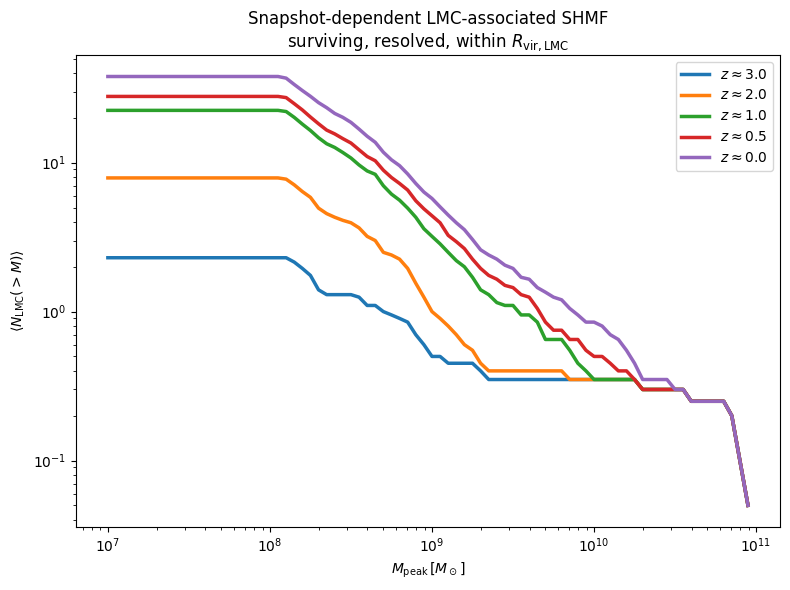

,host_index,host_name,lmc_idx,i_pre,z_infall_lmc,z_target,z_actual,snap,before_lmc_infall,N_lmc_assoc_before_cuts,N_selected_after_cuts,mp,m_res
0,0,Halo004,1,229,0.079488,3.0,3.012883,126,True,3,2,281981.0,84594300.0
1,0,Halo004,1,229,0.079488,2.0,1.993103,149,True,5,4,281981.0,84594300.0
2,0,Halo004,1,229,0.079488,1.0,0.990490,181,True,17,15,281981.0,84594300.0
3,0,Halo004,1,229,0.079488,0.5,0.503701,203,True,28,22,281981.0,84594300.0
4,0,Halo004,1,229,0.079488,0.0,0.000000,235,False,59,47,281981.0,84594300.0


,host_index,host_name,lmc_idx,sub_idx,is_lmc,i_pre,z_infall_lmc,z_target,z_actual,snap,...,mvir_snap,mvir_pre,ok_snap,ok_z0,mp,m_res,n_particle_proxy,r_lmc,rvir_lmc,within_lmc_rvir
0,0,Halo004,1,1,True,229,0.079488,3.0,3.012883,126,...,1.868572e+10,1.631429e+11,True,True,281981.0,84594300.0,604397.312500,0.000000,21.393024,True
1,0,Halo004,1,248,False,229,0.079488,3.0,3.012883,126,...,2.102857e+08,1.188000e+08,True,False,281981.0,84594300.0,749.797241,20.062693,21.393024,True
2,0,Halo004,1,1,True,229,0.079488,2.0,1.993103,149,...,5.087143e+10,1.631429e+11,True,True,281981.0,84594300.0,604397.312500,0.000000,39.690811,True
3,0,Halo004,1,151,False,229,0.079488,2.0,1.993103,149,...,2.694286e+08,3.625714e+07,True,True,281981.0,84594300.0,1383.071899,30.831188,39.690811,True
4,0,Halo004,1,222,False,229,0.079488,2.0,1.993103,149,...,5.277143e+07,1.168286e+07,True,True,281981.0,84594300.0,865.813171,17.201086,39.690811,True


In [32]:
selected_subhalo_df, per_host_z_df, shmf_z_df = analyze_lmc_assoc_shmf_snapshot_dependent(
    base_dir="/data/darkmatter/programs/symlib/standard/",
    suite_name="MWest",
    lmc_index_by_host=lmc_index_by_host,
    target_redshifts=[3.0, 2.0, 1.0, 0.5, 0.0],
    log_m_min=7,
    log_m_max=11,
    n_bin=80,
    pre_infall_mode="crossing",
    mass_def="mpeak",
    min_particles=300,
    require_survive_z0=False,
    require_within_lmc_rvir=True,
    include_lmc_itself=True,
    make_plot=True,
    verbose=True,
)

display(per_host_z_df.head())
display(selected_subhalo_df.head())

***SHMF for the SymphonyLMC suite***

In [33]:
def analyze_total_shmf_symphony_lmc_cut(
    base_dir,
    suite_name="SymphonyLMC",
    log_m_min=6,
    log_m_max=11,
    n_bin=80,
    mass_def="mvir_z0",      # use this to compare to Fig. 7 Mvir ~ 1e8
    min_particles=300,
    make_plot=True,
    verbose=True,
):
    bins = np.logspace(log_m_min, log_m_max, n_bin + 1)
    mass_bins = bins[:-1]

    total_curve = np.zeros(n_bin)
    selected_rows = []
    per_host_rows = []

    n_hosts = symlib.n_hosts(suite_name)
    n_used_hosts = 0

    for i_host in range(n_hosts):
        sim_dir = symlib.get_host_directory(base_dir, suite_name, i_host)
        host_name = os.path.basename(sim_dir.rstrip("/"))

        h, hist = symlib.read_subhalos(sim_dir)
        scale = symlib.scale_factors(sim_dir)

        mp = get_particle_mass_safe(sim_dir, scale)
        m_res = min_particles * mp

        if mass_def == "mpeak":
            masses = hist["mpeak"]
            xlab = r"$M_{\rm peak}\,[M_\odot]$"
        elif mass_def == "mvir_z0":
            masses = h[:, -1]["mvir"]
            xlab = r"$M_{\rm vir}(z=0)\,[M_\odot]$"
        else:
            raise ValueError("mass_def must be 'mpeak' or 'mvir_z0'")

        # distance from central host at z=0
        host_x = h[0, -1]["x"]
        sub_x = h[:, -1]["x"]
        r_host = np.sqrt(np.sum((sub_x - host_x) ** 2, axis=1))
        rvir_host = h[0, -1]["rvir"]

        keep = np.ones(len(h), dtype=bool)

        # 1. exclude central
        keep[0] = False

        # 2. survives / exists at z=0
        keep &= h["ok"][:, -1]

        # 3. inside host Rvir at z=0
        keep &= r_host < rvir_host

        # 4. >300 particle cut
        keep &= masses >= m_res

        # 5. safe finite mass
        keep &= np.isfinite(masses)
        keep &= masses > 0

        selected = np.where(keep)[0]
        selected_masses = masses[selected]

        n_hist, _ = np.histogram(selected_masses, bins=bins)
        cumulative = np.cumsum(n_hist[::-1])[::-1]

        total_curve += cumulative
        n_used_hosts += 1

        per_host_rows.append({
            "host_index": i_host,
            "host_name": host_name,
            "N_selected_subhalos": int(len(selected)),
            "mp": float(mp),
            "m_res_300_particles": float(m_res),
            "rvir_host_z0": float(rvir_host),
            "N_gt_1e8": int(np.sum(selected_masses > 1e8)),
        })

        for sub_idx in selected:
            selected_rows.append({
                "host_index": i_host,
                "host_name": host_name,
                "sub_idx": int(sub_idx),
                "mass_def": mass_def,
                "mass": float(masses[sub_idx]),
                "mpeak": float(hist["mpeak"][sub_idx]),
                "mvir_z0": float(h[sub_idx, -1]["mvir"]),
                "ok_z0": bool(h[sub_idx, -1]["ok"]),
                "r_host_z0": float(r_host[sub_idx]),
                "rvir_host_z0": float(rvir_host),
                "within_host_rvir": bool(r_host[sub_idx] < rvir_host),
                "n_particle_proxy": float(masses[sub_idx] / mp),
            })

        if verbose:
            print(
                f"{host_name}: N_selected={len(selected)}, "
                f"N(>1e8)={np.sum(selected_masses > 1e8)}, "
                f"m_res={m_res:.3e}"
            )

    total_curve /= n_used_hosts

    shmf_df = pd.DataFrame({
        "mass_bin_left_edge": mass_bins,
        "N_total_subhalos_cumulative": total_curve,
    })

    selected_subhalo_df = pd.DataFrame(selected_rows)
    per_host_df = pd.DataFrame(per_host_rows)

    if make_plot:
        mask = shmf_df["N_total_subhalos_cumulative"] > 0

        plt.figure(figsize=(8, 6))
        plt.plot(
            shmf_df.loc[mask, "mass_bin_left_edge"],
            shmf_df.loc[mask, "N_total_subhalos_cumulative"],
            linewidth=2.8,
            label="SymphonyLMC total subhalos, cut"
        )

        plt.axvline(1e8, linestyle="--", linewidth=1.5, label=r"$10^8 M_\odot$")

        plt.xscale("log")
        plt.yscale("log")
        plt.xlabel(xlab)
        plt.ylabel(r"$\langle N(>M)\rangle$")
        plt.title(
            r"Total SHMF: SymphonyLMC"
            "\n"
            r"surviving, $>300$ particles, within host $R_{\rm vir}$"
        )
        plt.legend()
        plt.tight_layout()
        plt.show()

    return selected_subhalo_df, per_host_df, shmf_df

Halo032: N_selected=67, N(>1e8)=8, m_res=1.057e+07
Halo059: N_selected=91, N(>1e8)=13, m_res=1.057e+07
Halo0662: N_selected=52, N(>1e8)=6, m_res=1.057e+07
Halo083: N_selected=51, N(>1e8)=7, m_res=1.057e+07
Halo088: N_selected=103, N(>1e8)=12, m_res=1.057e+07
Halo097: N_selected=50, N(>1e8)=5, m_res=1.057e+07
Halo104: N_selected=74, N(>1e8)=14, m_res=1.057e+07
Halo110: N_selected=69, N(>1e8)=11, m_res=1.057e+07
Halo202: N_selected=74, N(>1e8)=8, m_res=1.057e+07
Halo208: N_selected=83, N(>1e8)=8, m_res=1.057e+07
Halo218: N_selected=75, N(>1e8)=8, m_res=1.057e+07
Halo296: N_selected=108, N(>1e8)=24, m_res=1.057e+07
Halo301: N_selected=115, N(>1e8)=16, m_res=1.057e+07
Halo303: N_selected=62, N(>1e8)=9, m_res=1.057e+07
Halo340: N_selected=77, N(>1e8)=7, m_res=1.057e+07
Halo374: N_selected=58, N(>1e8)=9, m_res=1.057e+07
Halo380: N_selected=76, N(>1e8)=11, m_res=1.057e+07
Halo391: N_selected=72, N(>1e8)=12, m_res=1.057e+07
Halo405: N_selected=108, N(>1e8)=17, m_res=1.057e+07
Halo440: N_select

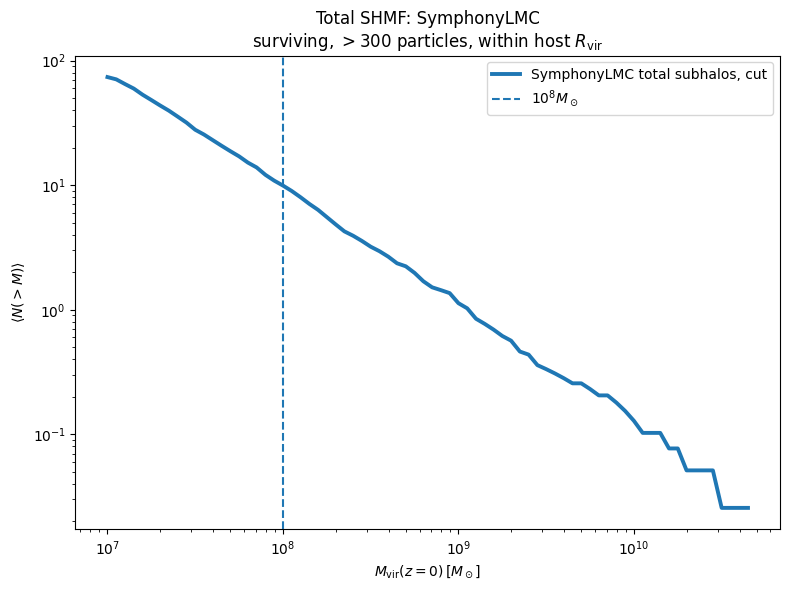

,host_index,host_name,N_selected_subhalos,mp,m_res_300_particles,rvir_host_z0,N_gt_1e8
0,0,Halo032,67,35247.6,10574280.0,119.279099,8
1,1,Halo059,91,35247.6,10574280.0,120.440292,13
2,2,Halo0662,52,35247.6,10574280.0,119.792099,6
3,3,Halo083,51,35247.6,10574280.0,124.059372,7
4,4,Halo088,103,35247.6,10574280.0,126.073883,12
5,5,Halo097,50,35247.6,10574280.0,120.799339,5
6,6,Halo104,74,35247.6,10574280.0,117.242935,14
7,7,Halo110,69,35247.6,10574280.0,123.977203,11
8,8,Halo202,74,35247.6,10574280.0,125.332733,8
9,9,Halo208,83,35247.6,10574280.0,117.298080,8


,host_index,host_name,sub_idx,mass_def,mass,mpeak,mvir_z0,ok_z0,r_host_z0,rvir_host_z0,within_host_rvir,n_particle_proxy
0,0,Halo032,2,mvir_z0,2.854286e+09,4.097143e+09,2.854286e+09,True,79.638924,119.279099,True,80978.156250
1,0,Halo032,3,mvir_z0,1.212000e+08,2.334286e+09,1.212000e+08,True,1.016910,119.279099,True,3438.531738
2,0,Halo032,4,mvir_z0,1.089143e+08,2.034286e+09,1.089143e+08,True,42.162960,119.279099,True,3089.977295
3,0,Halo032,9,mvir_z0,1.692857e+08,4.688572e+08,1.692857e+08,True,46.107674,119.279099,True,4802.758301
4,0,Halo032,10,mvir_z0,2.070000e+07,3.707143e+08,2.070000e+07,True,29.060446,119.279099,True,587.273987


,mass_bin_left_edge,N_total_subhalos_cumulative
0,1.000000e+07,73.743590
1,1.122018e+07,70.692308
2,1.258925e+07,64.794872
3,1.412538e+07,59.589744
4,1.584893e+07,53.230769


In [34]:
sym_lmc_selected_df, sym_lmc_per_host_df, sym_lmc_shmf_df = analyze_total_shmf_symphony_lmc_cut(
    base_dir=base_dir_SymphonyLMC,
    suite_name=suite_name_SymphonyLMC,
    log_m_min=7,
    log_m_max=11,
    n_bin=80,
    mass_def="mvir_z0",
    min_particles=300,
    make_plot=True,
    verbose=True,
)

display(sym_lmc_per_host_df)
display(sym_lmc_selected_df.head())
display(sym_lmc_shmf_df.head())

***Plotting the two SHMF against each other***

In [35]:
def plot_mwest_redshifts_vs_symphony_lmc_total_corrected(
    mwest_shmf_z_df,
    sym_lmc_shmf_df,
    sym_mass_def="mvir_z0",
    title=r"MWest LMC-associated SHMF vs. corrected SymphonyLMC total SHMF",
):
    plt.figure(figsize=(8, 6))

    # -----------------------------
    # MWest LMC-associated curves
    # -----------------------------
    for z in sorted(mwest_shmf_z_df["z_target"].unique(), reverse=True):
        df_z = mwest_shmf_z_df[
            mwest_shmf_z_df["z_target"] == z
        ].copy().sort_values("mass_bin_left_edge")

        mask = df_z["N_lmc_assoc_cumulative"] > 0

        plt.plot(
            df_z.loc[mask, "mass_bin_left_edge"],
            df_z.loc[mask, "N_lmc_assoc_cumulative"],
            linewidth=2.2,
            label=fr"MWest LMC-associated $z \approx {z:g}$",
        )

    # -----------------------------
    # Corrected SymphonyLMC total SHMF
    # -----------------------------
    sym_df = sym_lmc_shmf_df.copy().sort_values("mass_bin_left_edge")
    mask_sym = sym_df["N_total_subhalos_cumulative"] > 0

    plt.plot(
        sym_df.loc[mask_sym, "mass_bin_left_edge"],
        sym_df.loc[mask_sym, "N_total_subhalos_cumulative"],
        color="black",
        linewidth=3.2,
        linestyle="--",
        label=(
            r"SymphonyLMC total, corrected"
            "\n"
            r"surviving, $>300$ particles, within $R_{\rm vir}$"
        ),
    )

    plt.axvline(
        1e8,
        color="gray",
        linestyle=":",
        linewidth=1.5,
        label=r"$10^8\,M_\odot$",
    )

    plt.xscale("log")
    plt.yscale("log")

    if sym_mass_def == "mvir_z0":
        plt.xlabel(r"$M_{\rm vir}(z=0)\,[M_\odot]$")
        plt.ylabel(r"$\langle N(>M_{\rm vir})\rangle$")
    elif sym_mass_def == "mpeak":
        plt.xlabel(r"$M_{\rm peak}\,[M_\odot]$")
        plt.ylabel(r"$\langle N(>M_{\rm peak})\rangle$")
    else:
        plt.xlabel(r"$M\,[M_\odot]$")
        plt.ylabel(r"$\langle N(>M)\rangle$")

    plt.title(title)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

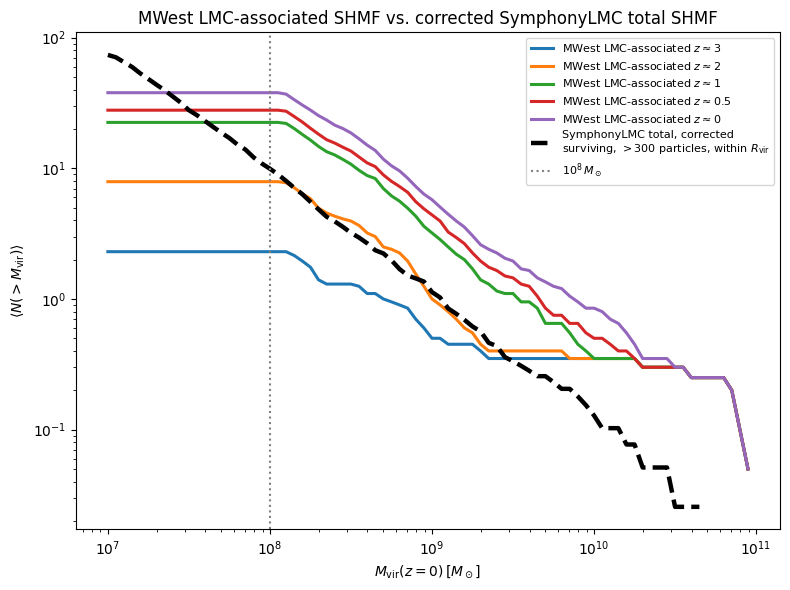

In [36]:
plot_mwest_redshifts_vs_symphony_lmc_total_corrected(
    mwest_shmf_z_df=shmf_z_df,
    sym_lmc_shmf_df=sym_lmc_shmf_df,
    sym_mass_def="mvir_z0",
)

***It might be interesting to look the SHMF using the current z = 0 mass***

Halo004: i_pre=229, z_infall=0.079
Halo113: i_pre=228, z_infall=0.093
Halo169: i_pre=224, z_infall=0.151
Halo170: i_pre=226, z_infall=0.122
Halo222: i_pre=230, z_infall=0.066
Halo229: i_pre=181, z_infall=0.990
Halo282: i_pre=231, z_infall=0.052
Halo327: i_pre=222, z_infall=0.180
Halo349: i_pre=219, z_infall=0.226
Halo407: i_pre=229, z_infall=0.079
Halo453: i_pre=224, z_infall=0.151
Halo476: i_pre=223, z_infall=0.165
Halo659: i_pre=188, z_infall=0.821
Halo666: i_pre=227, z_infall=0.107
Halo719: i_pre=229, z_infall=0.079
Halo747: i_pre=227, z_infall=0.107
Halo756: i_pre=227, z_infall=0.107
Halo788: i_pre=227, z_infall=0.107
Halo975: i_pre=228, z_infall=0.093
Halo983: i_pre=228, z_infall=0.093


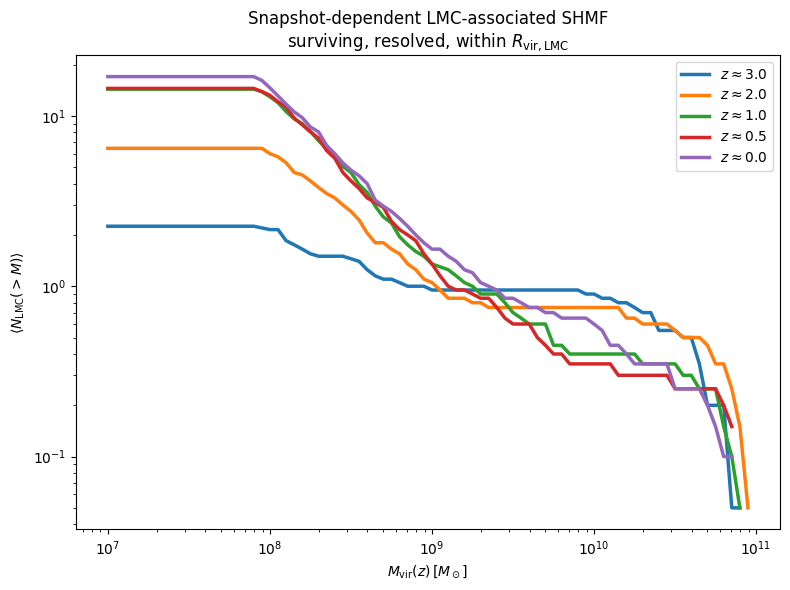

Halo032: N_selected=67, N(>1e8)=8, m_res=1.057e+07
Halo059: N_selected=91, N(>1e8)=13, m_res=1.057e+07
Halo0662: N_selected=52, N(>1e8)=6, m_res=1.057e+07
Halo083: N_selected=51, N(>1e8)=7, m_res=1.057e+07
Halo088: N_selected=103, N(>1e8)=12, m_res=1.057e+07
Halo097: N_selected=50, N(>1e8)=5, m_res=1.057e+07
Halo104: N_selected=74, N(>1e8)=14, m_res=1.057e+07
Halo110: N_selected=69, N(>1e8)=11, m_res=1.057e+07
Halo202: N_selected=74, N(>1e8)=8, m_res=1.057e+07
Halo208: N_selected=83, N(>1e8)=8, m_res=1.057e+07
Halo218: N_selected=75, N(>1e8)=8, m_res=1.057e+07
Halo296: N_selected=108, N(>1e8)=24, m_res=1.057e+07
Halo301: N_selected=115, N(>1e8)=16, m_res=1.057e+07
Halo303: N_selected=62, N(>1e8)=9, m_res=1.057e+07
Halo340: N_selected=77, N(>1e8)=7, m_res=1.057e+07
Halo374: N_selected=58, N(>1e8)=9, m_res=1.057e+07
Halo380: N_selected=76, N(>1e8)=11, m_res=1.057e+07
Halo391: N_selected=72, N(>1e8)=12, m_res=1.057e+07
Halo405: N_selected=108, N(>1e8)=17, m_res=1.057e+07
Halo440: N_select

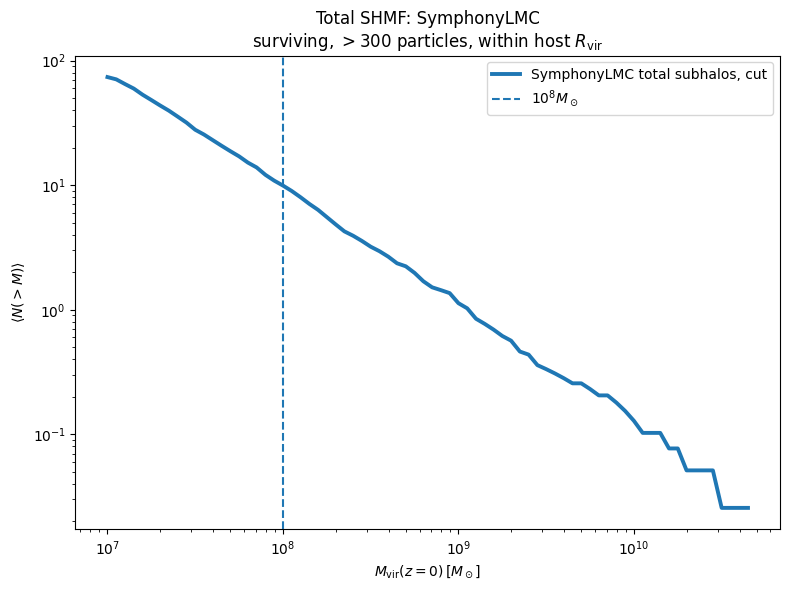

In [37]:
mwest_selected_current_df, mwest_per_host_current_df, mwest_shmf_current_z_df = analyze_lmc_assoc_shmf_snapshot_dependent(
    base_dir=base_dir,
    suite_name=suite_name,
    lmc_index_by_host=lmc_index_by_host,
    target_redshifts=[3.0, 2.0, 1.0, 0.5, 0.0],

    
    log_m_min=7,
    log_m_max=11,
    n_bin=80,

    pre_infall_mode="crossing",

    # key change
    mass_def="mvir_snap",

    min_particles=300,
    require_survive_z0=True,
    require_within_lmc_rvir=True,
    include_lmc_itself=True,

    make_plot=True,
    verbose=True,
)

sym_lmc_selected_current_df, sym_lmc_per_host_current_df, sym_lmc_shmf_current_df = analyze_total_shmf_symphony_lmc_cut(
    base_dir=base_dir_SymphonyLMC,
    suite_name=suite_name_SymphonyLMC,

    log_m_min=7,
    log_m_max=11,
    n_bin=80,

    # key choice for the z=0 comparison curve
    mass_def="mvir_z0",

    min_particles=300,
    make_plot=True,
    verbose=True,
)

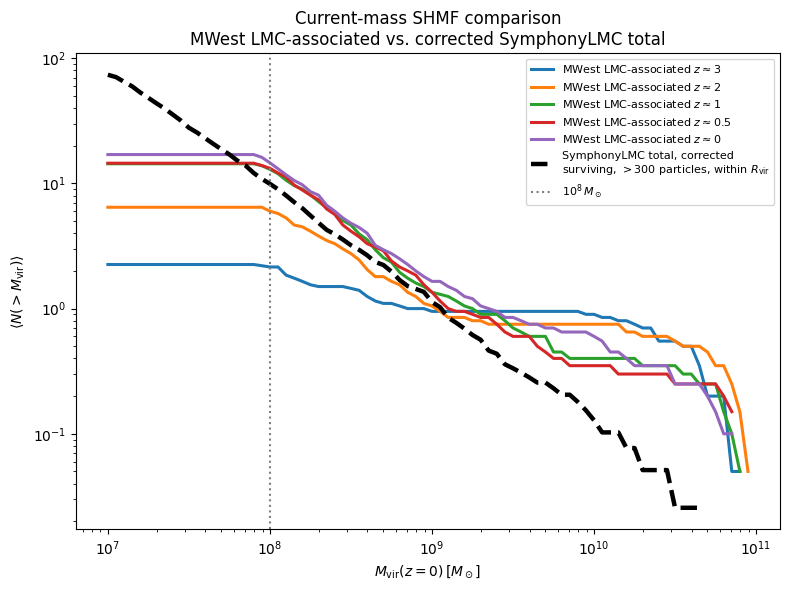

In [38]:
plot_mwest_redshifts_vs_symphony_lmc_total_corrected(
    mwest_shmf_z_df=mwest_shmf_current_z_df,
    sym_lmc_shmf_df=sym_lmc_shmf_current_df,
    sym_mass_def="mvir_z0",
    title=(
        r"Current-mass SHMF comparison"
        "\n"
        r"MWest LMC-associated vs. corrected SymphonyLMC total"
    ),
)

***Now, it is useful to look at how the SHMF looks like by normalizing them based on the host halos mass***

In [39]:
def analyze_mwest_lmc_assoc_shmf_mpeak_normalized(
    base_dir,
    suite_name,
    lmc_index_by_host,
    target_redshifts,
    log_mu_min=-6,
    log_mu_max=0,
    n_bin=80,
    pre_infall_mode="crossing",
    min_particles=300,
    require_survive_z0=True,
    require_within_lmc_rvir=True,
    include_lmc_itself=False,
    make_plot=True,
    verbose=True,
):
    """
    MWest LMC-associated SHMF using peak normalized mass:

        mu_peak = Mpeak_sub / Mpeak_LMC

    Cuts:
    - LMC-associated by the snapshot-dependent rule.
    - Exists at the target snapshot.
    - Optional survives to z=0.
    - Physical resolution cut: Mpeak_sub >= 300 * mp.
    - Optional within Rvir,LMC at the target snapshot.
    """

    bins = np.logspace(log_mu_min, log_mu_max, n_bin + 1)
    mu_bins = bins[:-1]

    curves_by_z = {z: np.zeros(n_bin) for z in target_redshifts}

    selected_rows = []
    per_host_rows = []
    curve_rows = []

    n_used_hosts = 0
    n_hosts = symlib.n_hosts(suite_name)

    for i_host in range(n_hosts):

        if i_host not in lmc_index_by_host:
            continue

        sim_dir = symlib.get_host_directory(base_dir, suite_name, i_host)
        host_name = os.path.basename(sim_dir.rstrip("/"))

        h, hist = symlib.read_subhalos(sim_dir)
        scale = symlib.scale_factors(sim_dir)
        redshifts = 1.0 / scale - 1.0

        lmc_idx = lmc_index_by_host[i_host]

        if lmc_idx <= 0 or lmc_idx >= len(h):
            if verbose:
                print(f"Skipping {host_name}: bad lmc_idx={lmc_idx}")
            continue

        i_pre = find_pre_infall_snapshot(
            h[0],
            h[lmc_idx],
            mode=pre_infall_mode,
        )

        if i_pre is None:
            if verbose:
                print(f"Skipping {host_name}: no pre-infall snapshot")
            continue

        mp = get_particle_mass_safe(sim_dir, scale)
        m_res = min_particles * mp

        sub_mpeak = hist["mpeak"]
        host_mpeak = hist["mpeak"][lmc_idx]

        if not np.isfinite(host_mpeak) or host_mpeak <= 0:
            if verbose:
                print(f"Skipping {host_name}: bad LMC Mpeak={host_mpeak}")
            continue

        mu_peak = sub_mpeak / host_mpeak

        membership_by_snap = build_lmc_membership_by_snapshot(
            h=h,
            lmc_idx=lmc_idx,
            i_pre=i_pre,
            include_lmc_itself=include_lmc_itself,
        )

        n_used_hosts += 1

        for z_target in target_redshifts:

            snap_z = int(np.argmin(np.abs(redshifts - z_target)))
            z_actual = float(redshifts[snap_z])

            current_lmc_assoc = membership_by_snap[snap_z].copy()

            keep = current_lmc_assoc.copy()

            # Must exist at target snapshot
            keep &= h["ok"][:, snap_z]

            # Optional z=0 survival cut
            if require_survive_z0:
                keep &= h["ok"][:, -1]

            # Resolution cut uses physical peak mass, not normalized mass
            keep &= sub_mpeak >= m_res

            # Finite normalized peak mass
            keep &= np.isfinite(mu_peak)
            keep &= mu_peak > 0

            # Optional distance cut relative to LMC analog at the target snapshot
            if require_within_lmc_rvir:

                if h[lmc_idx, snap_z]["ok"]:
                    sub_x = h[:, snap_z]["x"]
                    lmc_x = h[lmc_idx, snap_z]["x"]

                    r_lmc = np.sqrt(np.sum((sub_x - lmc_x) ** 2, axis=1))
                    rvir_lmc = h[lmc_idx, snap_z]["rvir"]

                    within_lmc_rvir = r_lmc < rvir_lmc
                    keep &= within_lmc_rvir
                else:
                    r_lmc = np.full(len(h), np.nan)
                    rvir_lmc = np.nan
                    keep[:] = False

            else:
                if h[lmc_idx, snap_z]["ok"]:
                    sub_x = h[:, snap_z]["x"]
                    lmc_x = h[lmc_idx, snap_z]["x"]
                    r_lmc = np.sqrt(np.sum((sub_x - lmc_x) ** 2, axis=1))
                    rvir_lmc = h[lmc_idx, snap_z]["rvir"]
                else:
                    r_lmc = np.full(len(h), np.nan)
                    rvir_lmc = np.nan

            selected = np.where(keep)[0]
            selected_mu = mu_peak[selected]

            n_hist, _ = np.histogram(selected_mu, bins=bins)
            cumulative = np.cumsum(n_hist[::-1])[::-1]

            curves_by_z[z_target] += cumulative

            per_host_rows.append({
                "host_index": i_host,
                "host_name": host_name,
                "lmc_idx": int(lmc_idx),
                "i_pre": int(i_pre),
                "z_infall_lmc": float(redshifts[i_pre]),
                "z_target": float(z_target),
                "z_actual": z_actual,
                "snap": int(snap_z),
                "Mpeak_LMC": float(host_mpeak),
                "mp": float(mp),
                "m_res_300_particles": float(m_res),
                "N_lmc_assoc_before_cuts": int(np.sum(current_lmc_assoc)),
                "N_selected_after_cuts": int(len(selected)),
                "N_mu_peak_gt_1e_minus_4": int(np.sum(selected_mu > 1e-4)),
            })

            for sub_idx in selected:
                selected_rows.append({
                    "host_index": i_host,
                    "host_name": host_name,
                    "lmc_idx": int(lmc_idx),
                    "sub_idx": int(sub_idx),
                    "is_lmc": bool(sub_idx == lmc_idx),

                    "z_target": float(z_target),
                    "z_actual": z_actual,
                    "snap": int(snap_z),

                    "Mpeak_sub": float(sub_mpeak[sub_idx]),
                    "Mpeak_LMC": float(host_mpeak),
                    "mu_peak": float(mu_peak[sub_idx]),

                    "mvir_snap": float(h[sub_idx, snap_z]["mvir"]) if h[sub_idx, snap_z]["ok"] else np.nan,
                    "ok_snap": bool(h[sub_idx, snap_z]["ok"]),
                    "ok_z0": bool(h[sub_idx, -1]["ok"]),

                    "mp": float(mp),
                    "m_res_300_particles": float(m_res),
                    "n_particle_proxy_peak": float(sub_mpeak[sub_idx] / mp),

                    "r_lmc": float(r_lmc[sub_idx]) if np.isfinite(r_lmc[sub_idx]) else np.nan,
                    "rvir_lmc": float(rvir_lmc) if np.isfinite(rvir_lmc) else np.nan,
                    "within_lmc_rvir": (
                        bool(r_lmc[sub_idx] < rvir_lmc)
                        if np.isfinite(r_lmc[sub_idx]) and np.isfinite(rvir_lmc)
                        else False
                    ),
                })

        if verbose:
            print(
                f"{host_name}: "
                f"LMC Mpeak={host_mpeak:.3e}, "
                f"i_pre={i_pre}, "
                f"z_infall={redshifts[i_pre]:.3f}"
            )

    if n_used_hosts == 0:
        raise RuntimeError("No MWest hosts were successfully analyzed.")

    for z_target in target_redshifts:
        curves_by_z[z_target] /= n_used_hosts

        for mu_left, n in zip(mu_bins, curves_by_z[z_target]):
            curve_rows.append({
                "z_target": float(z_target),
                "mu_peak_bin_left_edge": float(mu_left),
                "N_lmc_assoc_cumulative": float(n),
            })

    selected_df = pd.DataFrame(selected_rows)
    per_host_df = pd.DataFrame(per_host_rows)
    shmf_df = pd.DataFrame(curve_rows)

    if make_plot:
        plt.figure(figsize=(8, 6))

        for z_target in sorted(target_redshifts, reverse=True):
            df_z = shmf_df[shmf_df["z_target"] == z_target].copy()
            df_z = df_z.sort_values("mu_peak_bin_left_edge")

            mask = df_z["N_lmc_assoc_cumulative"] > 0

            plt.plot(
                df_z.loc[mask, "mu_peak_bin_left_edge"],
                df_z.loc[mask, "N_lmc_assoc_cumulative"],
                linewidth=2.4,
                label=fr"$z \approx {z_target:g}$",
            )

        plt.axvline(
            1.4e-4,
            linestyle=":",
            linewidth=1.5,
            label=r"$1.4\times10^{-4}$",
        )

        plt.xscale("log")
        plt.yscale("log")
        plt.xlabel(r"$\mu_{\rm peak}=M_{\rm peak,sub}/M_{\rm peak,LMC}$")
        plt.ylabel(r"$\langle N(>\mu_{\rm peak})\rangle$")
        plt.title(
            r"MWest LMC-associated peak-normalized SHMF"
            "\n"
            r"surviving, resolved, within $R_{\rm vir,LMC}$"
        )
        plt.legend(fontsize=8)
        plt.tight_layout()
        plt.show()

    return selected_df, per_host_df, shmf_df

In [40]:
def analyze_symphony_lmc_total_shmf_mpeak_normalized(
    base_dir,
    suite_name="SymphonyLMC",
    log_mu_min=-6,
    log_mu_max=0,
    n_bin=80,
    min_particles=300,
    make_plot=True,
    verbose=True,
):
    """
    SymphonyLMC total SHMF using peak normalized mass:

        mu_peak = Mpeak_sub / Mpeak_host

    Cuts:
    - Exclude central host.
    - Survives / exists at z=0.
    - Inside host Rvir at z=0.
    - Physical resolution cut: Mpeak_sub >= 300 * mp.
    """

    bins = np.logspace(log_mu_min, log_mu_max, n_bin + 1)
    mu_bins = bins[:-1]

    total_curve = np.zeros(n_bin)
    selected_rows = []
    per_host_rows = []

    n_hosts = symlib.n_hosts(suite_name)
    n_used_hosts = 0

    for i_host in range(n_hosts):

        sim_dir = symlib.get_host_directory(base_dir, suite_name, i_host)
        host_name = os.path.basename(sim_dir.rstrip("/"))

        h, hist = symlib.read_subhalos(sim_dir)
        scale = symlib.scale_factors(sim_dir)

        mp = get_particle_mass_safe(sim_dir, scale)
        m_res = min_particles * mp

        sub_mpeak = hist["mpeak"]
        host_mpeak = hist["mpeak"][0]

        if not np.isfinite(host_mpeak) or host_mpeak <= 0:
            if verbose:
                print(f"Skipping {host_name}: bad host Mpeak={host_mpeak}")
            continue

        mu_peak = sub_mpeak / host_mpeak

        # z=0 distance from central host
        host_x = h[0, -1]["x"]
        sub_x = h[:, -1]["x"]

        r_host = np.sqrt(np.sum((sub_x - host_x) ** 2, axis=1))
        rvir_host = h[0, -1]["rvir"]

        keep = np.ones(len(h), dtype=bool)

        # Exclude central host
        keep[0] = False

        # Survives / exists at z=0
        keep &= h["ok"][:, -1]

        # Inside host Rvir at z=0
        keep &= r_host < rvir_host

        # Resolution cut using physical Mpeak
        keep &= sub_mpeak >= m_res

        # Finite normalized peak mass
        keep &= np.isfinite(mu_peak)
        keep &= mu_peak > 0

        selected = np.where(keep)[0]
        selected_mu = mu_peak[selected]

        n_hist, _ = np.histogram(selected_mu, bins=bins)
        cumulative = np.cumsum(n_hist[::-1])[::-1]

        total_curve += cumulative
        n_used_hosts += 1

        per_host_rows.append({
            "host_index": i_host,
            "host_name": host_name,
            "Mpeak_host": float(host_mpeak),
            "mp": float(mp),
            "m_res_300_particles": float(m_res),
            "rvir_host_z0": float(rvir_host),
            "N_selected_subhalos": int(len(selected)),
            "N_mu_peak_gt_1e_minus_4": int(np.sum(selected_mu > 1e-4)),
        })

        for sub_idx in selected:
            selected_rows.append({
                "host_index": i_host,
                "host_name": host_name,
                "sub_idx": int(sub_idx),

                "Mpeak_sub": float(sub_mpeak[sub_idx]),
                "Mpeak_host": float(host_mpeak),
                "mu_peak": float(mu_peak[sub_idx]),

                "mvir_z0": float(h[sub_idx, -1]["mvir"]),
                "ok_z0": bool(h[sub_idx, -1]["ok"]),

                "r_host_z0": float(r_host[sub_idx]),
                "rvir_host_z0": float(rvir_host),
                "within_host_rvir": bool(r_host[sub_idx] < rvir_host),

                "mp": float(mp),
                "m_res_300_particles": float(m_res),
                "n_particle_proxy_peak": float(sub_mpeak[sub_idx] / mp),
            })

        if verbose:
            print(
                f"{host_name}: "
                f"N_selected={len(selected)}, "
                f"N(mu_peak > 1e-4)={np.sum(selected_mu > 1e-4)}, "
                f"Mpeak_host={host_mpeak:.3e}, "
                f"m_res={m_res:.3e}"
            )

    if n_used_hosts == 0:
        raise RuntimeError("No SymphonyLMC hosts were successfully analyzed.")

    total_curve /= n_used_hosts

    shmf_df = pd.DataFrame({
        "mu_peak_bin_left_edge": mu_bins,
        "N_total_subhalos_cumulative": total_curve,
    })

    selected_df = pd.DataFrame(selected_rows)
    per_host_df = pd.DataFrame(per_host_rows)

    if make_plot:
        mask = shmf_df["N_total_subhalos_cumulative"] > 0

        plt.figure(figsize=(8, 6))
        plt.plot(
            shmf_df.loc[mask, "mu_peak_bin_left_edge"],
            shmf_df.loc[mask, "N_total_subhalos_cumulative"],
            linewidth=2.8,
            label="SymphonyLMC total, corrected",
        )

        plt.axvline(
            1.4e-4,
            linestyle=":",
            linewidth=1.5,
            label=r"$1.4\times10^{-4}$",
        )

        plt.xscale("log")
        plt.yscale("log")
        plt.xlabel(r"$\mu_{\rm peak}=M_{\rm peak,sub}/M_{\rm peak,host}$")
        plt.ylabel(r"$\langle N(>\mu_{\rm peak})\rangle$")
        plt.title(
            r"Corrected SymphonyLMC peak-normalized total SHMF"
            "\n"
            r"surviving, $>300$ particles, within host $R_{\rm vir}$"
        )
        plt.legend(fontsize=8)
        plt.tight_layout()
        plt.show()

    return selected_df, per_host_df, shmf_df

In [41]:
def plot_mwest_vs_symphony_lmc_mpeak_normalized(
    mwest_shmf_mu_peak_z_df,
    sym_lmc_shmf_mu_peak_df,
    title=(
        r"Peak-normalized SHMF comparison"
        "\n"
        r"MWest LMC-associated vs. corrected SymphonyLMC total"
    ),
):
    plt.figure(figsize=(8, 6))

    # Mwest
    for z in sorted(mwest_shmf_mu_peak_z_df["z_target"].unique(), reverse=True):

        df_z = mwest_shmf_mu_peak_z_df[
            mwest_shmf_mu_peak_z_df["z_target"] == z
        ].copy()

        df_z = df_z.sort_values("mu_peak_bin_left_edge")

        mask = df_z["N_lmc_assoc_cumulative"] > 0

        plt.plot(
            df_z.loc[mask, "mu_peak_bin_left_edge"],
            df_z.loc[mask, "N_lmc_assoc_cumulative"],
            linewidth=2.2,
            label=fr"MWest LMC-associated $z \approx {z:g}$",
        )

    # SymphonyLMC
    sym_df = sym_lmc_shmf_mu_peak_df.copy()
    sym_df = sym_df.sort_values("mu_peak_bin_left_edge")

    mask_sym = sym_df["N_total_subhalos_cumulative"] > 0

    plt.plot(
        sym_df.loc[mask_sym, "mu_peak_bin_left_edge"],
        sym_df.loc[mask_sym, "N_total_subhalos_cumulative"],
        color="black",
        linewidth=3.2,
        linestyle="--",
        label=(
            r"SymphonyLMC total, corrected"
            "\n"
            r"surviving, $>300$ particles, within $R_{\rm vir}$"
        ),
    )

    plt.axvline(
        1.4e-4,
        color="gray",
        linestyle=":",
        linewidth=1.5,
        label=r"$1.4\times10^{-4}$",
    )

    plt.xscale("log")
    plt.yscale("log")

    plt.xlabel(r"$\mu_{\rm peak}=M_{\rm peak,sub}/M_{\rm peak,host}$")
    plt.ylabel(r"$\langle N(>\mu_{\rm peak})\rangle$")

    plt.title(title)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

Halo004: LMC Mpeak=1.704e+11, i_pre=229, z_infall=0.079
Halo113: LMC Mpeak=3.633e+10, i_pre=228, z_infall=0.093
Halo169: LMC Mpeak=2.289e+11, i_pre=224, z_infall=0.151
Halo170: LMC Mpeak=2.667e+11, i_pre=226, z_infall=0.122
Halo222: LMC Mpeak=2.654e+11, i_pre=230, z_infall=0.066
Halo229: LMC Mpeak=1.866e+10, i_pre=181, z_infall=0.990
Halo282: LMC Mpeak=7.081e+10, i_pre=231, z_infall=0.052
Halo327: LMC Mpeak=1.412e+11, i_pre=222, z_infall=0.180
Halo349: LMC Mpeak=2.876e+11, i_pre=219, z_infall=0.226
Halo407: LMC Mpeak=9.586e+10, i_pre=229, z_infall=0.079
Halo453: LMC Mpeak=3.297e+11, i_pre=224, z_infall=0.151
Halo476: LMC Mpeak=2.500e+11, i_pre=223, z_infall=0.165
Halo659: LMC Mpeak=7.973e+10, i_pre=188, z_infall=0.821
Halo666: LMC Mpeak=6.319e+11, i_pre=227, z_infall=0.107
Halo719: LMC Mpeak=4.630e+11, i_pre=229, z_infall=0.079
Halo747: LMC Mpeak=7.336e+10, i_pre=227, z_infall=0.107
Halo756: LMC Mpeak=1.674e+11, i_pre=227, z_infall=0.107
Halo788: LMC Mpeak=6.779e+10, i_pre=227, z_infal

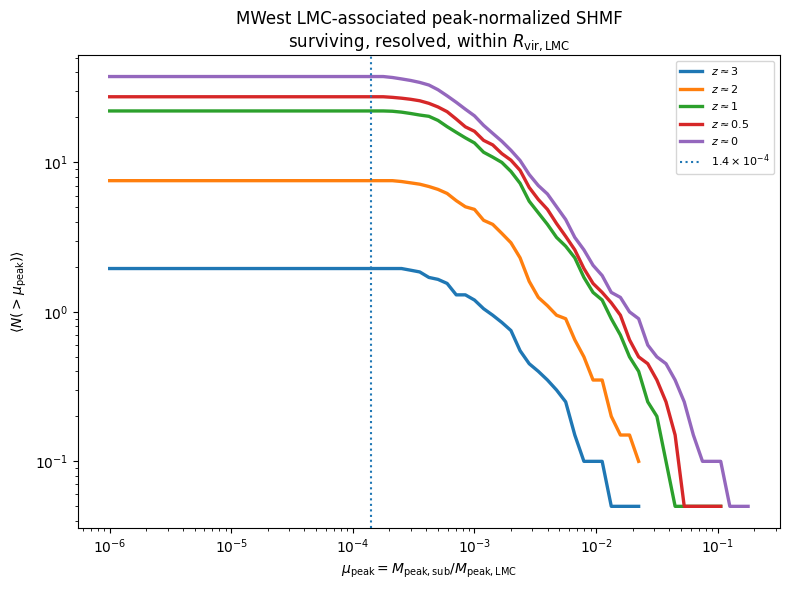

,host_index,host_name,lmc_idx,i_pre,z_infall_lmc,z_target,z_actual,snap,Mpeak_LMC,mp,m_res_300_particles,N_lmc_assoc_before_cuts,N_selected_after_cuts,N_mu_peak_gt_1e_minus_4
0,0,Halo004,1,229,0.079488,3.0,3.012883,126,1.704286e+11,281981.0,84594300.0,2,1,1
1,0,Halo004,1,229,0.079488,2.0,1.993103,149,1.704286e+11,281981.0,84594300.0,4,3,3
2,0,Halo004,1,229,0.079488,1.0,0.990490,181,1.704286e+11,281981.0,84594300.0,16,14,14
3,0,Halo004,1,229,0.079488,0.5,0.503701,203,1.704286e+11,281981.0,84594300.0,27,21,21
4,0,Halo004,1,229,0.079488,0.0,0.000000,235,1.704286e+11,281981.0,84594300.0,58,46,46


,host_index,host_name,lmc_idx,sub_idx,is_lmc,z_target,z_actual,snap,Mpeak_sub,Mpeak_LMC,mu_peak,mvir_snap,ok_snap,ok_z0,mp,m_res_300_particles,n_particle_proxy_peak,r_lmc,rvir_lmc,within_lmc_rvir
0,0,Halo004,1,248,False,3.0,3.012883,126,211428576.0,1.704286e+11,0.001241,210285712.0,True,False,281981.0,84594300.0,749.797241,20.062693,21.393024,True
1,0,Halo004,1,151,False,2.0,1.993103,149,390000000.0,1.704286e+11,0.002288,269428576.0,True,True,281981.0,84594300.0,1383.071899,30.831188,39.690811,True
2,0,Halo004,1,222,False,2.0,1.993103,149,244142864.0,1.704286e+11,0.001433,52771428.0,True,True,281981.0,84594300.0,865.813171,17.201086,39.690811,True
3,0,Halo004,1,223,False,2.0,1.993103,149,271142848.0,1.704286e+11,0.001591,144285712.0,True,True,281981.0,84594300.0,961.564270,35.658833,39.690811,True
4,0,Halo004,1,74,False,1.0,0.990490,181,835428608.0,1.704286e+11,0.004902,165142864.0,True,True,281981.0,84594300.0,2962.712402,9.873079,69.611885,True


,z_target,mu_peak_bin_left_edge,N_lmc_assoc_cumulative
0,3.0,0.000001,1.95
1,3.0,0.000001,1.95
2,3.0,0.000001,1.95
3,3.0,0.000002,1.95
4,3.0,0.000002,1.95


In [42]:
mwest_selected_mu_peak_df, mwest_per_host_mu_peak_df, mwest_shmf_mu_peak_z_df = analyze_mwest_lmc_assoc_shmf_mpeak_normalized(
    base_dir=base_dir,
    suite_name=suite_name,
    lmc_index_by_host=lmc_index_by_host,
    target_redshifts=target_redshifts,

    log_mu_min=-6,
    log_mu_max=0,
    n_bin=80,

    pre_infall_mode="crossing",

    min_particles=300,
    require_survive_z0=False,
    require_within_lmc_rvir=True,
    include_lmc_itself=False,

    make_plot=True,
    verbose=True,
)

display(mwest_per_host_mu_peak_df.head())
display(mwest_selected_mu_peak_df.head())
display(mwest_shmf_mu_peak_z_df.head())

Halo032: N_selected=141, N(mu_peak > 1e-4)=141, Mpeak_host=9.591e+10, m_res=1.057e+07
Halo059: N_selected=164, N(mu_peak > 1e-4)=164, Mpeak_host=9.874e+10, m_res=1.057e+07
Halo0662: N_selected=121, N(mu_peak > 1e-4)=121, Mpeak_host=9.716e+10, m_res=1.057e+07
Halo083: N_selected=93, N(mu_peak > 1e-4)=93, Mpeak_host=1.079e+11, m_res=1.057e+07
Halo088: N_selected=195, N(mu_peak > 1e-4)=195, Mpeak_host=1.133e+11, m_res=1.057e+07
Halo097: N_selected=108, N(mu_peak > 1e-4)=108, Mpeak_host=1.013e+11, m_res=1.057e+07
Halo104: N_selected=120, N(mu_peak > 1e-4)=120, Mpeak_host=9.109e+10, m_res=1.057e+07
Halo110: N_selected=131, N(mu_peak > 1e-4)=131, Mpeak_host=1.077e+11, m_res=1.057e+07
Halo202: N_selected=149, N(mu_peak > 1e-4)=149, Mpeak_host=1.113e+11, m_res=1.057e+07
Halo208: N_selected=143, N(mu_peak > 1e-4)=143, Mpeak_host=9.177e+10, m_res=1.057e+07
Halo218: N_selected=161, N(mu_peak > 1e-4)=161, Mpeak_host=1.066e+11, m_res=1.057e+07
Halo296: N_selected=194, N(mu_peak > 1e-4)=194, Mpeak_h

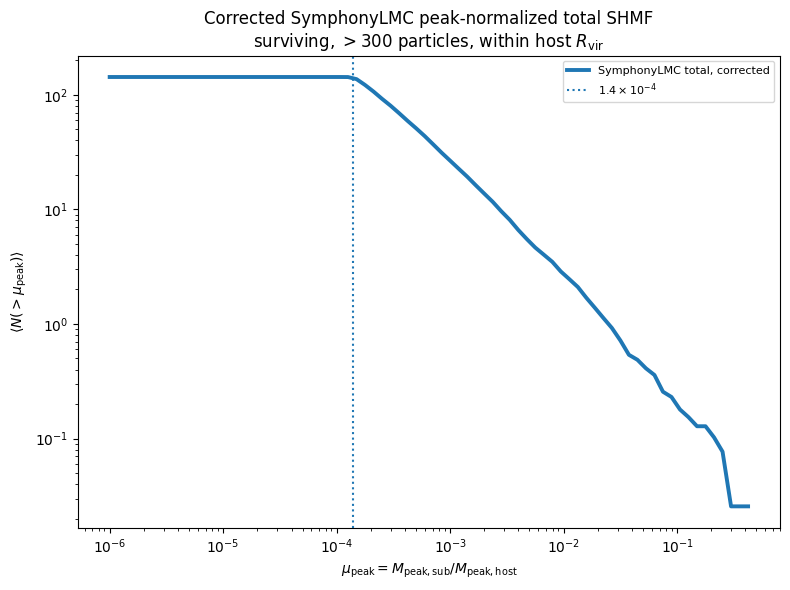

,host_index,host_name,Mpeak_host,mp,m_res_300_particles,rvir_host_z0,N_selected_subhalos,N_mu_peak_gt_1e_minus_4
0,0,Halo032,9.591429e+10,35247.6,10574280.0,119.279099,141,141
1,1,Halo059,9.874286e+10,35247.6,10574280.0,120.440292,164,164
2,2,Halo0662,9.715714e+10,35247.6,10574280.0,119.792099,121,121
3,3,Halo083,1.079143e+11,35247.6,10574280.0,124.059372,93,93
4,4,Halo088,1.132571e+11,35247.6,10574280.0,126.073883,195,195


,host_index,host_name,sub_idx,Mpeak_sub,Mpeak_host,mu_peak,mvir_z0,ok_z0,r_host_z0,rvir_host_z0,within_host_rvir,mp,m_res_300_particles,n_particle_proxy_peak
0,0,Halo032,2,4.097143e+09,9.591429e+10,0.042717,2.854286e+09,True,79.638924,119.279099,True,35247.6,10574280.0,116238.914062
1,0,Halo032,3,2.334286e+09,9.591429e+10,0.024337,1.212000e+08,True,1.016910,119.279099,True,35247.6,10574280.0,66225.382812
2,0,Halo032,4,2.034286e+09,9.591429e+10,0.021209,1.089143e+08,True,42.162960,119.279099,True,35247.6,10574280.0,57714.160156
3,0,Halo032,9,4.688572e+08,9.591429e+10,0.004888,1.692857e+08,True,46.107674,119.279099,True,35247.6,10574280.0,13301.817383
4,0,Halo032,10,3.707143e+08,9.591429e+10,0.003865,2.070000e+07,True,29.060446,119.279099,True,35247.6,10574280.0,10517.433594


,mu_peak_bin_left_edge,N_total_subhalos_cumulative
0,0.000001,142.897436
1,0.000001,142.897436
2,0.000001,142.897436
3,0.000002,142.897436
4,0.000002,142.897436


In [43]:
sym_lmc_selected_mu_peak_df, sym_lmc_per_host_mu_peak_df, sym_lmc_shmf_mu_peak_df = analyze_symphony_lmc_total_shmf_mpeak_normalized(
    base_dir=base_dir_SymphonyLMC,
    suite_name=suite_name_SymphonyLMC,

    log_mu_min=-6,
    log_mu_max=0,
    n_bin=80,

    min_particles=300,

    make_plot=True,
    verbose=True,
)

display(sym_lmc_per_host_mu_peak_df.head())
display(sym_lmc_selected_mu_peak_df.head())
display(sym_lmc_shmf_mu_peak_df.head())

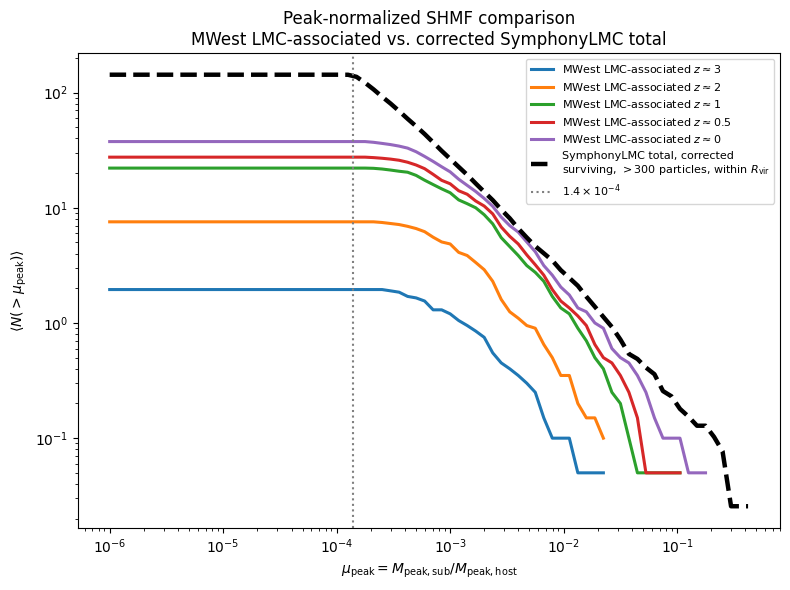

In [44]:
plot_mwest_vs_symphony_lmc_mpeak_normalized(
    mwest_shmf_mu_peak_z_df=mwest_shmf_mu_peak_z_df,
    sym_lmc_shmf_mu_peak_df=sym_lmc_shmf_mu_peak_df,
    title=(
        r"Peak-normalized SHMF comparison"
        "\n"
        r"MWest LMC-associated vs. corrected SymphonyLMC total"
    ),
)

In [25]:
\

TypeError: plot_mwest_vs_symphony_lmc_mpeak_normalized() got an unexpected keyword argument 'base_dir'

***Now it is interesting to look at the mass accretion history of the host halos of the LMC analogs compared to the SymphonyLMC suite, normalizing them to various mass points***

## Mass-Accretion History Normalizations

### 1. Absolute Mass

The first comparison uses the raw virial mass of each halo as a function of scale factor:

$$
y(a) = M_{\rm vir}(a).
$$

For the Milky Way-est sample, this corresponds to the virial mass history of the selected LMC analog subhalo. For the SymphonyLMC sample, this corresponds to the virial mass history of the central LMC-mass host halo. This normalization preserves the physical mass scale of each system and allows us to check whether the two samples occupy comparable halo-mass ranges.

---

### 2. Final-Mass Normalized MAH

A common normalization is to divide each mass-accretion history by the final available halo mass:

$$
y(a) =
\frac{M_{\rm vir}(a)}
{M_{\rm vir}(a_{\rm final})}.
$$

This forces each halo to approach unity at its final snapshot, so the stacked curves emphasize relative growth history rather than absolute mass. This is similar to the normalization used in many host-halo MAH comparisons.

For isolated host halos, such as the SymphonyLMC central halos, this normalization is straightforward. For Milky Way-est LMC analogs, however, the final bound virial mass may be affected by tidal evolution after infall into the Milky Way host.

---

### 3. Peak-Mass Normalized MAH

Another useful normalization divides each halo history by its peak historical mass:

$$
y(a) =
\frac{M_{\rm vir}(a)}
{M_{\rm peak}}.
$$

Here $M_{\rm peak}$ is the maximum mass reached by the halo over its resolved history. This normalization is useful for LMC analogs because their present-day bound mass can be reduced after infall due to stripping. Normalizing by $M_{\rm peak}$ therefore compares each object relative to its largest historical mass rather than its potentially stripped final mass.

---

### 4. Pre-Infall Normalized MAH

For Milky Way-est LMC analogs, a physically motivated normalization is the mass at the final snapshot before the LMC analog falls into the Milky Way host:

$$
y(a) =
\frac{M_{\rm vir}(a)}
{M_{\rm vir}(a_{\rm pre})}.
$$

Here $a_{\rm pre}$ is the scale factor of the last snapshot before LMC infall. This normalization measures how much of the LMC analog's pre-infall mass had assembled by each scale factor.

For SymphonyLMC, there is no direct equivalent of $a_{\rm pre}$, since these halos are isolated LMC-mass hosts rather than subhalos falling into a Milky Way-mass system. Therefore, the SymphonyLMC comparison can be normalized at a reference scale factor,

$$
a_{\rm ref} =
{\rm median}(a_{\rm pre,MWest}),
$$

so that

$$
y_{\rm SymphonyLMC}(a) =
\frac{M_{\rm vir}(a)}
{M_{\rm vir}(a_{\rm ref})}.
$$

---

### 5. Reference-Scale Normalized MAH

The reference-scale normalization is a more general version of the pre-infall normalization:

$$
y(a) =
\frac{M_{\rm vir}(a)}
{M_{\rm vir}(a_{\rm ref})}.
$$

In this analysis, $a_{\rm ref}$ is chosen to match a characteristic evolutionary time of the Milky Way-est LMC analogs, such as the median pre-infall scale factor. This allows isolated SymphonyLMC hosts to be compared to Milky Way-est LMC analogs at a matched reference epoch.

---

### 6. Pre-Infall-Only MWest MAH

In addition to changing the normalization, the Milky Way-est LMC analog histories can also be restricted to the pre-infall regime:

$$
a \leq a_{\rm pre}.
$$

The corresponding normalized quantity is

$$
y(a) =
\frac{M_{\rm vir}(a)}
{M_{\rm vir}(a_{\rm pre})},
\qquad a \leq a_{\rm pre}.
$$

This removes the post-infall evolution of the LMC analog, where the object becomes a subhalo of the Milky Way and may experience tidal stripping. The resulting curve isolates the host-like growth phase of the LMC analog before it enters the Milky Way system.

In [20]:
# More helper functions
def interpolate_mah_to_grid(a, m, ok, a_grid):
    """
    Interpolate log10(M) onto a common scale-factor grid.

    Only uses snapshots where:
    - ok is True
    - mass is finite
    - mass > 0

    Returns linear mass on a_grid, with NaNs outside valid range.
    """
    a = np.asarray(a)
    m = np.asarray(m)
    ok = np.asarray(ok, dtype=bool)

    good = ok & np.isfinite(a) & np.isfinite(m) & (m > 0)

    if np.sum(good) < 2:
        return np.full_like(a_grid, np.nan, dtype=float)

    a_good = a[good]
    logm_good = np.log10(m[good])

    # enforce sorted unique scale factors
    order = np.argsort(a_good)
    a_good = a_good[order]
    logm_good = logm_good[order]

    unique_a, unique_idx = np.unique(a_good, return_index=True)
    logm_good = logm_good[unique_idx]

    out = np.full_like(a_grid, np.nan, dtype=float)

    inside = (a_grid >= unique_a.min()) & (a_grid <= unique_a.max())
    out[inside] = 10 ** np.interp(a_grid[inside], unique_a, logm_good)

    return out


def summarize_curves(curves, a_grid):
    """
    Stack MAH curves and return median, mean, 16/84, and 2.5/97.5 bands.
    """
    curves = np.asarray(curves, dtype=float)

    rows = []
    for j, a in enumerate(a_grid):
        vals = curves[:, j]
        vals = vals[np.isfinite(vals)]

        if len(vals) == 0:
            rows.append({
                "a": a,
                "n": 0,
                "mean": np.nan,
                "median": np.nan,
                "p16": np.nan,
                "p84": np.nan,
                "p2p5": np.nan,
                "p97p5": np.nan,
            })
        else:
            rows.append({
                "a": a,
                "n": len(vals),
                "mean": np.mean(vals),
                "median": np.median(vals),
                "p16": np.percentile(vals, 16),
                "p84": np.percentile(vals, 84),
                "p2p5": np.percentile(vals, 2.5),
                "p97p5": np.percentile(vals, 97.5),
            })

    return pd.DataFrame(rows)

In [21]:
#MAH of MWest
def collect_mwest_lmc_analog_mahs(
    base_dir,
    suite_name,
    lmc_index_by_host,
    pre_infall_mode="crossing",
    a_grid=None,
    normalize="none",
    norm_a_ref=0.8,
    use_only_pre_infall=False,
    verbose=True,
):
    """
    Collect mass-accretion histories for MWest LMC analogs.

    Each MWest object is the selected LMC analog subhalo inside a MW-est host.

    normalize options:
    - "none": absolute Mvir(a)
    - "final": Mvir(a) / Mvir(a_final)
    - "z0": same as final
    - "peak": Mvir(a) / Mpeak
    - "pre": Mvir(a) / Mvir(a_pre), where a_pre is final snapshot before MW infall
    - "at_scale": Mvir(a) / Mvir(a_ref), e.g. a_ref = 0.8

    use_only_pre_infall:
    - False: keep entire available LMC analog history
    - True: mask snapshots after a_pre, useful if you want pure pre-infall growth only
    """
    if a_grid is None:
        a_grid = np.linspace(0.05, 1.0, 220)

    curves = []
    rows = []

    n_hosts = symlib.n_hosts(suite_name)

    for i_host in range(n_hosts):

        if i_host not in lmc_index_by_host:
            continue

        sim_dir = symlib.get_host_directory(base_dir, suite_name, i_host)
        host_name = os.path.basename(sim_dir.rstrip("/"))

        h, hist = symlib.read_subhalos(sim_dir)
        scale = symlib.scale_factors(sim_dir)

        lmc_idx = int(lmc_index_by_host[i_host])

        if lmc_idx <= 0 or lmc_idx >= len(h):
            if verbose:
                print(f"Skipping {host_name}: bad lmc_idx={lmc_idx}")
            continue

        i_pre = find_pre_infall_snapshot(
            h[0],
            h[lmc_idx],
            mode=pre_infall_mode,
        )

        if i_pre is None:
            if verbose:
                print(f"Skipping {host_name}: no pre-infall snapshot")
            continue

        a_pre = float(scale[i_pre])
        z_pre = 1.0 / a_pre - 1.0

        mvir = h[lmc_idx, :]["mvir"].astype(float)
        ok = h[lmc_idx, :]["ok"].astype(bool)

        if use_only_pre_infall:
            ok = ok.copy()
            ok[scale > a_pre] = False

        m_interp = interpolate_mah_to_grid(scale, mvir, ok, a_grid)

        # -----------------------------
        # Normalization
        # -----------------------------
        if normalize in ["none", None]:
            norm = 1.0
            norm_label = "absolute"

        elif normalize in ["final", "z0"]:
            good_final = ok & np.isfinite(mvir) & (mvir > 0)
            if np.sum(good_final) == 0:
                continue
            norm = mvir[np.where(good_final)[0][-1]]
            norm_label = "final"

        elif normalize == "peak":
            norm = float(hist["mpeak"][lmc_idx])
            norm_label = "mpeak"

        elif normalize == "pre":
            if not ok[i_pre] or not np.isfinite(mvir[i_pre]) or mvir[i_pre] <= 0:
                continue
            norm = float(mvir[i_pre])
            norm_label = "pre-infall"

        elif normalize == "at_scale":
            m_ref = interpolate_mah_to_grid(scale, mvir, ok, np.array([norm_a_ref]))[0]
            if not np.isfinite(m_ref) or m_ref <= 0:
                continue
            norm = float(m_ref)
            norm_label = f"a={norm_a_ref:g}"

        else:
            raise ValueError(
                "normalize must be one of: none, final, z0, peak, pre, at_scale"
            )

        if not np.isfinite(norm) or norm <= 0:
            continue

        y = m_interp / norm
        curves.append(y)

        rows.append({
            "suite": suite_name,
            "sample": "MWest LMC analog",
            "host_index": i_host,
            "host_name": host_name,
            "lmc_idx": lmc_idx,
            "i_pre": int(i_pre),
            "a_pre": a_pre,
            "z_pre": z_pre,
            "mvir_pre": float(mvir[i_pre]) if ok[i_pre] else np.nan,
            "mvir_final_good": float(norm) if normalize in ["final", "z0"] else np.nan,
            "mpeak": float(hist["mpeak"][lmc_idx]),
            "normalization": norm_label,
            "norm_value": float(norm),
            "use_only_pre_infall": bool(use_only_pre_infall),
        })

        if verbose:
            print(
                f"{host_name}: LMC idx={lmc_idx}, "
                f"a_pre={a_pre:.3f}, z_pre={z_pre:.3f}, "
                f"Mpre={mvir[i_pre]:.3e}, Mpeak={hist['mpeak'][lmc_idx]:.3e}"
            )

    if len(curves) == 0:
        raise RuntimeError("No MWest LMC analog MAHs were collected.")

    curves = np.asarray(curves)
    per_host_df = pd.DataFrame(rows)
    summary_df = summarize_curves(curves, a_grid)

    return per_host_df, summary_df, curves

In [22]:
#MAH of SymphonyLMC
def collect_symphony_lmc_host_mahs(
    base_dir,
    suite_name="SymphonyLMC",
    a_grid=None,
    normalize="none",
    norm_a_ref=0.8,
    verbose=True,
):
    """
    Collect MAHs for central host halos in the SymphonyLMC suite.

    Here the central host h[0] is the LMC-mass host.

    normalize options:
    - "none": absolute Mvir(a)
    - "final": Mvir(a) / Mvir(a_final)
    - "z0": same as final
    - "peak": Mvir(a) / Mpeak of central host
    - "at_scale": Mvir(a) / Mvir(a_ref), e.g. a_ref = 0.8

    Note: "pre" is not defined for SymphonyLMC because these are isolated
    LMC-mass hosts, not LMC analogs falling into a MW host.
    """
    if a_grid is None:
        a_grid = np.linspace(0.05, 1.0, 220)

    curves = []
    rows = []

    n_hosts = symlib.n_hosts(suite_name)

    for i_host in range(n_hosts):

        sim_dir = symlib.get_host_directory(base_dir, suite_name, i_host)
        host_name = os.path.basename(sim_dir.rstrip("/"))

        h, hist = symlib.read_subhalos(sim_dir)
        scale = symlib.scale_factors(sim_dir)

        host_idx = 0

        mvir = h[host_idx, :]["mvir"].astype(float)
        ok = h[host_idx, :]["ok"].astype(bool)

        m_interp = interpolate_mah_to_grid(scale, mvir, ok, a_grid)

        # -----------------------------
        # Normalization
        # -----------------------------
        if normalize in ["none", None]:
            norm = 1.0
            norm_label = "absolute"

        elif normalize in ["final", "z0"]:
            good_final = ok & np.isfinite(mvir) & (mvir > 0)
            if np.sum(good_final) == 0:
                continue
            norm = mvir[np.where(good_final)[0][-1]]
            norm_label = "final"

        elif normalize == "peak":
            norm = float(hist["mpeak"][host_idx])
            norm_label = "mpeak"

        elif normalize == "at_scale":
            m_ref = interpolate_mah_to_grid(scale, mvir, ok, np.array([norm_a_ref]))[0]
            if not np.isfinite(m_ref) or m_ref <= 0:
                continue
            norm = float(m_ref)
            norm_label = f"a={norm_a_ref:g}"

        elif normalize == "pre":
            raise ValueError(
                "normalize='pre' is only meaningful for MWest LMC analogs. "
                "Use normalize='at_scale' for SymphonyLMC instead."
            )

        else:
            raise ValueError(
                "normalize must be one of: none, final, z0, peak, at_scale"
            )

        if not np.isfinite(norm) or norm <= 0:
            continue

        y = m_interp / norm
        curves.append(y)

        rows.append({
            "suite": suite_name,
            "sample": "SymphonyLMC central host",
            "host_index": i_host,
            "host_name": host_name,
            "host_idx": host_idx,
            "mvir_final_good": float(norm) if normalize in ["final", "z0"] else np.nan,
            "mpeak": float(hist["mpeak"][host_idx]),
            "normalization": norm_label,
            "norm_value": float(norm),
        })

        if verbose:
            print(
                f"{host_name}: central host, "
                f"Mfinal/norm={norm:.3e}, Mpeak={hist['mpeak'][host_idx]:.3e}"
            )

    if len(curves) == 0:
        raise RuntimeError("No SymphonyLMC host MAHs were collected.")

    curves = np.asarray(curves)
    per_host_df = pd.DataFrame(rows)
    summary_df = summarize_curves(curves, a_grid)

    return per_host_df, summary_df, curves

Halo004: LMC idx=1, a_pre=0.926, z_pre=0.079, Mpre=1.631e+11, Mpeak=1.704e+11
Halo113: LMC idx=5, a_pre=0.915, z_pre=0.093, Mpre=3.507e+10, Mpeak=3.633e+10
Halo169: LMC idx=1, a_pre=0.869, z_pre=0.151, Mpre=2.249e+11, Mpeak=2.289e+11
Halo170: LMC idx=1, a_pre=0.892, z_pre=0.122, Mpre=2.520e+11, Mpeak=2.667e+11
Halo222: LMC idx=1, a_pre=0.938, z_pre=0.066, Mpre=2.546e+11, Mpeak=2.654e+11
Halo229: LMC idx=7, a_pre=0.502, z_pre=0.990, Mpre=1.816e+10, Mpeak=1.866e+10
Halo282: LMC idx=4, a_pre=0.950, z_pre=0.052, Mpre=6.810e+10, Mpeak=7.081e+10
Halo327: LMC idx=2, a_pre=0.847, z_pre=0.180, Mpre=1.404e+11, Mpeak=1.412e+11
Halo349: LMC idx=1, a_pre=0.815, z_pre=0.226, Mpre=2.876e+11, Mpeak=2.876e+11
Halo407: LMC idx=2, a_pre=0.926, z_pre=0.079, Mpre=8.917e+10, Mpeak=9.586e+10
Halo453: LMC idx=1, a_pre=0.869, z_pre=0.151, Mpre=3.127e+11, Mpeak=3.297e+11
Halo476: LMC idx=1, a_pre=0.858, z_pre=0.165, Mpre=2.154e+11, Mpeak=2.500e+11
Halo659: LMC idx=2, a_pre=0.549, z_pre=0.821, Mpre=7.973e+10, Mp

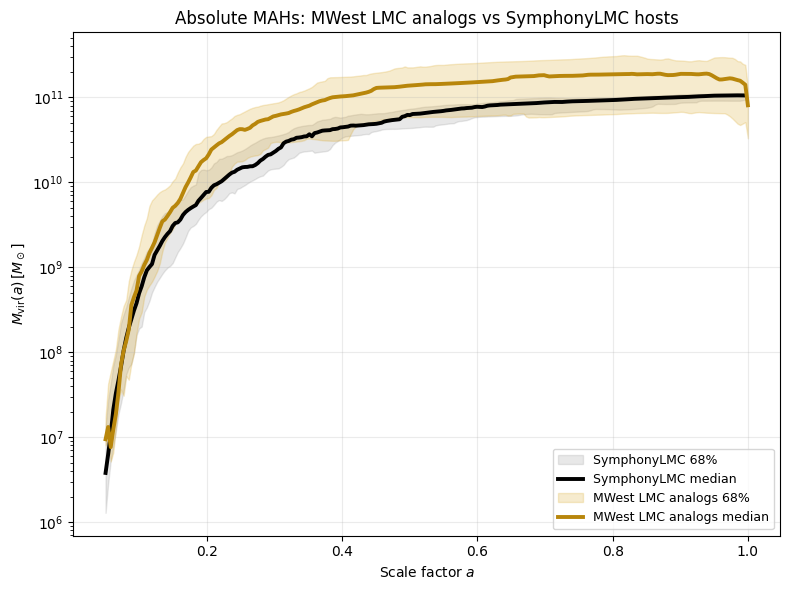

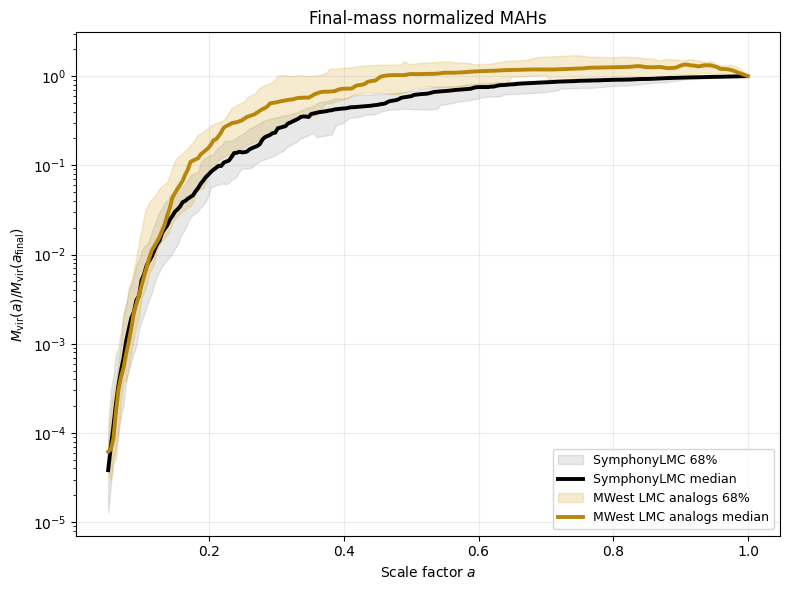

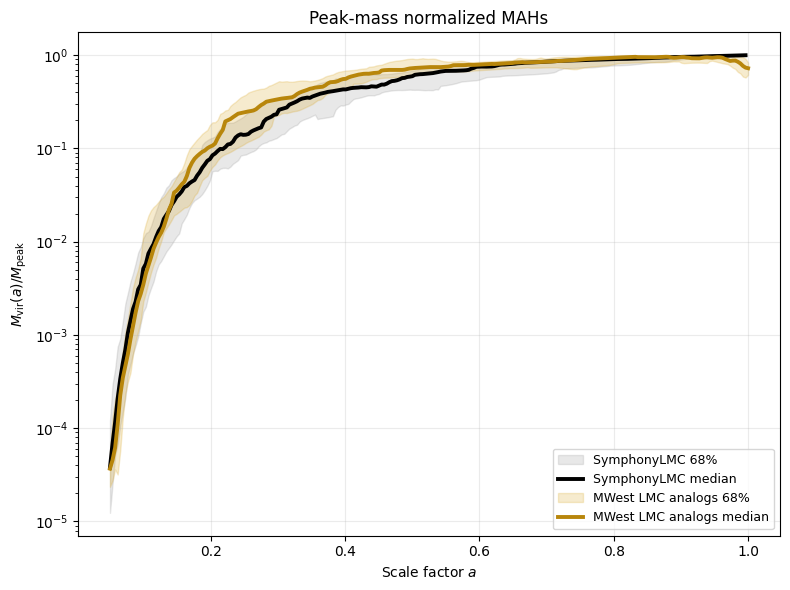

Median MWest LMC pre-infall scale factor: a_pre = 0.903


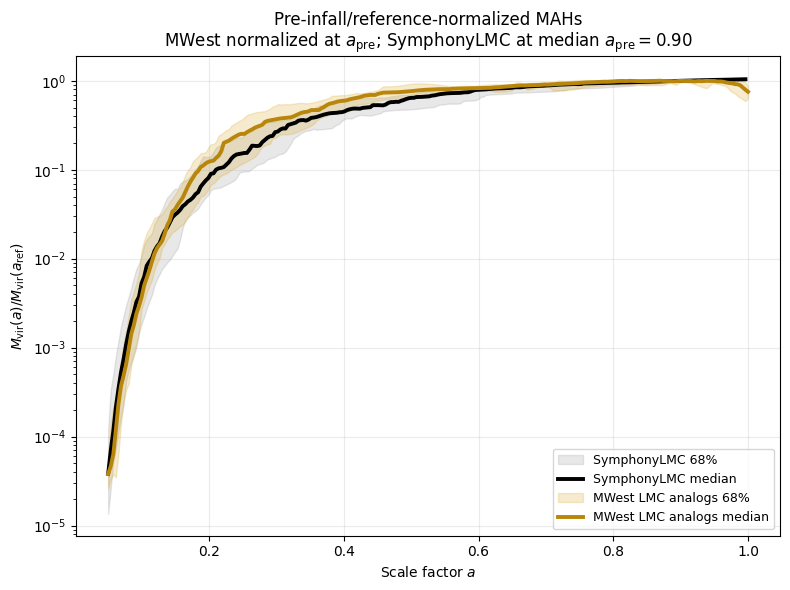

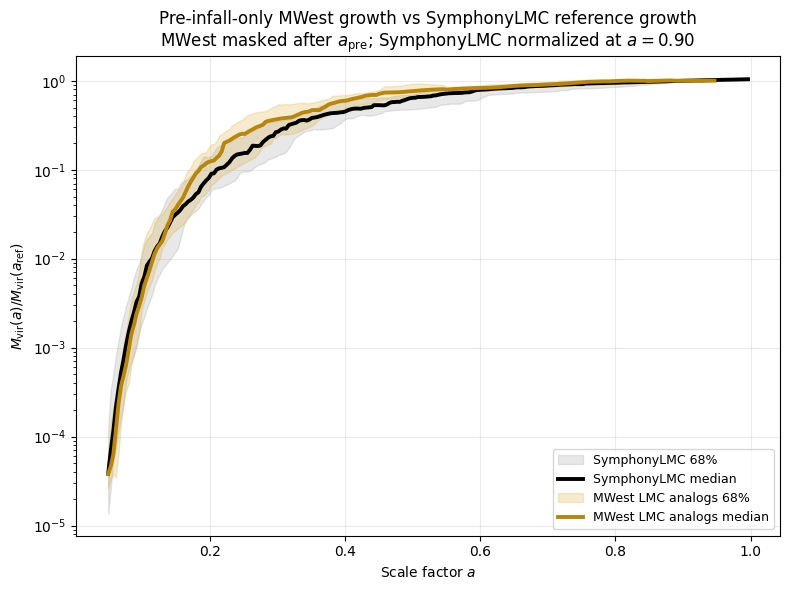

,suite,sample,host_index,host_name,lmc_idx,i_pre,a_pre,z_pre,mvir_pre,mvir_final_good,mpeak,normalization,norm_value,use_only_pre_infall
0,MWest,MWest LMC analog,0,Halo004,1,229,0.926365,0.079488,1.631429e+11,NaN,1.704286e+11,absolute,1.0,False
1,MWest,MWest LMC analog,1,Halo113,5,228,0.914632,0.093336,3.507143e+10,NaN,3.632857e+10,absolute,1.0,False
2,MWest,MWest LMC analog,2,Halo169,1,224,0.869163,0.150533,2.248572e+11,NaN,2.288572e+11,absolute,1.0,False
3,MWest,MWest LMC analog,3,Halo170,1,226,0.891607,0.121570,2.520000e+11,NaN,2.667143e+11,absolute,1.0,False
4,MWest,MWest LMC analog,4,Halo222,1,230,0.938251,0.065813,2.545714e+11,NaN,2.654286e+11,absolute,1.0,False


,suite,sample,host_index,host_name,host_idx,mvir_final_good,mpeak,normalization,norm_value
0,SymphonyLMC,SymphonyLMC central host,0,Halo032,0,NaN,9.591429e+10,absolute,1.0
1,SymphonyLMC,SymphonyLMC central host,1,Halo059,0,NaN,9.874286e+10,absolute,1.0
2,SymphonyLMC,SymphonyLMC central host,2,Halo0662,0,NaN,9.715714e+10,absolute,1.0
3,SymphonyLMC,SymphonyLMC central host,3,Halo083,0,NaN,1.079143e+11,absolute,1.0
4,SymphonyLMC,SymphonyLMC central host,4,Halo088,0,NaN,1.132571e+11,absolute,1.0


,a,n,mean,median,p16,p84,p2p5,p97p5
0,0.050000,4,1.248715e+07,9.467151e+06,8.057146e+06,1.715875e+07,8.057146e+06,2.205115e+07
1,0.053815,7,2.309550e+07,1.319798e+07,9.004998e+06,4.272302e+07,3.702547e+06,6.097001e+07
2,0.057631,13,2.520945e+07,7.654286e+06,5.188849e+06,5.872606e+07,4.339602e+06,9.572336e+07
3,0.061446,15,3.807157e+07,1.245052e+07,6.612319e+06,7.938795e+07,4.440262e+06,1.638537e+08
4,0.065261,17,5.533510e+07,1.875215e+07,1.320007e+07,1.088841e+08,7.358116e+06,2.250679e+08


,a,n,mean,median,p16,p84,p2p5,p97p5
0,0.050000,28,6.119476e+06,3.802143e+06,1.288932e+06,1.304343e+07,5.236433e+05,1.805857e+07
1,0.053815,37,1.378293e+07,6.286929e+06,2.859292e+06,2.769758e+07,1.165198e+06,4.817595e+07
2,0.057631,37,2.244338e+07,1.086766e+07,5.265874e+06,4.313477e+07,1.488820e+06,7.532015e+07
3,0.061446,38,3.536816e+07,2.117271e+07,7.866307e+06,6.983665e+07,2.519549e+06,1.254325e+08
4,0.065261,38,5.328888e+07,3.294763e+07,1.174947e+07,9.385019e+07,3.422920e+06,2.051727e+08


In [23]:
# plotting functions
def plot_mah_comparison(
    mwest_summary,
    sym_summary,
    ylabel,
    title,
    show_bands=True,
    show_mean=False,
    yscale="linear",
    savepath=None,
):
    """
    Plot MWest LMC-analog MAH vs SymphonyLMC central-host MAH.
    """
    fig, ax = plt.subplots(figsize=(8, 6))

    # SymphonyLMC
    sym = sym_summary.copy()
    mask_sym = np.isfinite(sym["median"])

    if show_bands:
        ax.fill_between(
            sym.loc[mask_sym, "a"],
            sym.loc[mask_sym, "p16"],
            sym.loc[mask_sym, "p84"],
            alpha=0.18,
            color="gray",
            label=r"SymphonyLMC 68%",
        )

    ax.plot(
        sym.loc[mask_sym, "a"],
        sym.loc[mask_sym, "median"],
        color="black",
        linewidth=2.8,
        label=r"SymphonyLMC median",
    )

    if show_mean:
        ax.plot(
            sym.loc[mask_sym, "a"],
            sym.loc[mask_sym, "mean"],
            color="black",
            linestyle=":",
            linewidth=2.0,
            label=r"SymphonyLMC mean",
        )

    #MWest LMC analogs
    mw = mwest_summary.copy()
    mask_mw = np.isfinite(mw["median"])

    if show_bands:
        ax.fill_between(
            mw.loc[mask_mw, "a"],
            mw.loc[mask_mw, "p16"],
            mw.loc[mask_mw, "p84"],
            alpha=0.22,
            color="goldenrod",
            label=r"MWest LMC analogs 68%",
        )

    ax.plot(
        mw.loc[mask_mw, "a"],
        mw.loc[mask_mw, "median"],
        color="darkgoldenrod",
        linewidth=2.8,
        label=r"MWest LMC analogs median",
    )

    if show_mean:
        ax.plot(
            mw.loc[mask_mw, "a"],
            mw.loc[mask_mw, "mean"],
            color="darkgoldenrod",
            linestyle=":",
            linewidth=2.0,
            label=r"MWest LMC analogs mean",
        )

    ax.set_xlabel(r"Scale factor $a$")
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    if yscale is not None:
        ax.set_yscale(yscale)

    ax.legend(fontsize=9)
    ax.grid(alpha=0.25)
    plt.tight_layout()

    if savepath is not None:
        plt.savefig(savepath, dpi=250, bbox_inches="tight")

    plt.show()


#Normalizations

# Scale factor grid
a_grid = np.linspace(0.05, 1.0, 250)


# Absolute Mass Comparision
mwest_abs_hosts, mwest_abs_summary, mwest_abs_curves = collect_mwest_lmc_analog_mahs(
    base_dir="/data/darkmatter/programs/symlib/standard/",
    suite_name="MWest",
    lmc_index_by_host=lmc_index_by_host,
    pre_infall_mode="crossing",
    a_grid=a_grid,
    normalize="none",
    use_only_pre_infall=False,
    verbose=True,
)

sym_abs_hosts, sym_abs_summary, sym_abs_curves = collect_symphony_lmc_host_mahs(
    base_dir=base_dir_SymphonyLMC,
    suite_name=suite_name_SymphonyLMC,
    a_grid=a_grid,
    normalize="none",
    verbose=True,
)

plot_mah_comparison(
    mwest_summary=mwest_abs_summary,
    sym_summary=sym_abs_summary,
    ylabel=r"$M_{\rm vir}(a)\,[M_\odot]$",
    title=r"Absolute MAHs: MWest LMC analogs vs SymphonyLMC hosts",
    show_bands=True,
    show_mean=False,
    yscale="log",
    savepath="mah_absolute_mwest_lmc_vs_symphony_lmc.png",
)


# Final mass normalization (Similar to Figure 6. from the MWest paper)

mwest_final_hosts, mwest_final_summary, mwest_final_curves = collect_mwest_lmc_analog_mahs(
    base_dir="/data/darkmatter/programs/symlib/standard/",
    suite_name="MWest",
    lmc_index_by_host=lmc_index_by_host,
    pre_infall_mode="crossing",
    a_grid=a_grid,
    normalize="final",
    use_only_pre_infall=False,
    verbose=False,
)

sym_final_hosts, sym_final_summary, sym_final_curves = collect_symphony_lmc_host_mahs(
    base_dir=base_dir_SymphonyLMC,
    suite_name=suite_name_SymphonyLMC,
    a_grid=a_grid,
    normalize="final",
    verbose=False,
)

plot_mah_comparison(
    mwest_summary=mwest_final_summary,
    sym_summary=sym_final_summary,
    ylabel=r"$M_{\rm vir}(a)/M_{\rm vir}(a_{\rm final})$",
    title=r"Final-mass normalized MAHs",
    show_bands=True,
    show_mean=False,
    yscale="log",
    savepath="mah_final_normalized_mwest_lmc_vs_symphony_lmc.png",
)


# Peak mass normalization

mwest_peak_hosts, mwest_peak_summary, mwest_peak_curves = collect_mwest_lmc_analog_mahs(
    base_dir="/data/darkmatter/programs/symlib/standard/",
    suite_name="MWest",
    lmc_index_by_host=lmc_index_by_host,
    pre_infall_mode="crossing",
    a_grid=a_grid,
    normalize="peak",
    use_only_pre_infall=False,
    verbose=False,
)

sym_peak_hosts, sym_peak_summary, sym_peak_curves = collect_symphony_lmc_host_mahs(
    base_dir=base_dir_SymphonyLMC,
    suite_name=suite_name_SymphonyLMC,
    a_grid=a_grid,
    normalize="peak",
    verbose=False,
)

plot_mah_comparison(
    mwest_summary=mwest_peak_summary,
    sym_summary=sym_peak_summary,
    ylabel=r"$M_{\rm vir}(a)/M_{\rm peak}$",
    title=r"Peak-mass normalized MAHs",
    show_bands=True,
    show_mean=False,
    yscale="log",
    savepath="mah_mpeak_normalized_mwest_lmc_vs_symphony_lmc.png",
)



# MWest pre-infall normalized comparison
# For SymphonyLMC, normalize at the median MWest pre-infall scale.

median_a_pre = float(np.nanmedian(mwest_abs_hosts["a_pre"]))
print(f"Median MWest LMC pre-infall scale factor: a_pre = {median_a_pre:.3f}")

mwest_pre_hosts, mwest_pre_summary, mwest_pre_curves = collect_mwest_lmc_analog_mahs(
    base_dir="/data/darkmatter/programs/symlib/standard/",
    suite_name="MWest",
    lmc_index_by_host=lmc_index_by_host,
    pre_infall_mode="crossing",
    a_grid=a_grid,
    normalize="pre",
    use_only_pre_infall=False,
    verbose=False,
)

sym_ref_hosts, sym_ref_summary, sym_ref_curves = collect_symphony_lmc_host_mahs(
    base_dir=base_dir_SymphonyLMC,
    suite_name=suite_name_SymphonyLMC,
    a_grid=a_grid,
    normalize="at_scale",
    norm_a_ref=median_a_pre,
    verbose=False,
)

plot_mah_comparison(
    mwest_summary=mwest_pre_summary,
    sym_summary=sym_ref_summary,
    ylabel=fr"$M_{{\rm vir}}(a)/M_{{\rm vir}}(a_{{\rm ref}})$",
    title=(
        r"Pre-infall/reference-normalized MAHs"
        "\n"
        fr"MWest normalized at $a_{{\rm pre}}$; SymphonyLMC at median $a_{{\rm pre}}={median_a_pre:.2f}$"
    ),
    show_bands=True,
    show_mean=False,
    yscale="log",
    savepath="mah_preinfall_reference_normalized_mwest_lmc_vs_symphony_lmc.png",
)


# Pure pre-infall growth of MWest LMC analogs only


mwest_preonly_hosts, mwest_preonly_summary, mwest_preonly_curves = collect_mwest_lmc_analog_mahs(
    base_dir="/data/darkmatter/programs/symlib/standard/",
    suite_name="MWest",
    lmc_index_by_host=lmc_index_by_host,
    pre_infall_mode="crossing",
    a_grid=a_grid,
    normalize="pre",
    use_only_pre_infall=True,
    verbose=False,
)

plot_mah_comparison(
    mwest_summary=mwest_preonly_summary,
    sym_summary=sym_ref_summary,
    ylabel=fr"$M_{{\rm vir}}(a)/M_{{\rm vir}}(a_{{\rm ref}})$",
    title=(
        r"Pre-infall-only MWest growth vs SymphonyLMC reference growth"
        "\n"
        fr"MWest masked after $a_{{\rm pre}}$; SymphonyLMC normalized at $a={median_a_pre:.2f}$"
    ),
    show_bands=True,
    show_mean=False,
    yscale="log",
    savepath="mah_preinfall_only_mwest_lmc_vs_symphony_lmc.png",
)


# ============================================================
# 5) Inspect host-level metadata
# ============================================================

display(mwest_abs_hosts.head())
display(sym_abs_hosts.head())

display(mwest_abs_summary.head())
display(sym_abs_summary.head())